In [2]:
import pandas as pd

In [3]:

df = pd.read_excel("../data/civicfix_complaints_final.xlsx")

print(df.shape)
df.head()

(4217, 8)


,complaint_id,complaint_text,is_civic,area,sub_category,department,severity,source_type
0,CF00001,A pothole in the road near the colony entrance...,1,Roads & Footpaths,Pothole,Roads / Municipal Engineering,Low,synthetic_curated
1,CF00002,People living nearby say a deep pothole along ...,1,Roads & Footpaths,Pothole,Roads / Municipal Engineering,Medium,synthetic_curated
2,CF00003,The area has been affected by a large road cra...,1,Roads & Footpaths,Pothole,Roads / Municipal Engineering,Medium,synthetic_curated
3,CF00004,The problem involves several potholes on the l...,1,Roads & Footpaths,Pothole,Roads / Municipal Engineering,High,synthetic_curated
4,CF00005,The civic issue was noticed along the resident...,1,Roads & Footpaths,Pothole,Roads / Municipal Engineering,Low,synthetic_curated


In [4]:
print(df.shape)

(4217, 8)


In [5]:
print(df.columns.tolist())

['complaint_id', 'complaint_text', 'is_civic', 'area', 'sub_category', 'department', 'severity', 'source_type']


In [6]:
df.isnull().sum()

complaint_id        0
complaint_text      0
is_civic            0
area              717
sub_category      717
department        717
severity          717
source_type         0
dtype: int64

In [7]:
print("Missing values:")
print(df.isnull().sum())

print("\nExact duplicate texts:")
print(df["complaint_text"].duplicated().sum())

print("\nCivic distribution:")
print(df["is_civic"].value_counts())

print("\nArea distribution:")
print(df[df["is_civic"] == 1]["area"].value_counts())

print("\nSeverity distribution:")
print(df[df["is_civic"] == 1]["severity"].value_counts())

Missing values:
complaint_id        0
complaint_text      0
is_civic            0
area              717
sub_category      717
department        717
severity          717
source_type         0
dtype: int64

Exact duplicate texts:
0

Civic distribution:
is_civic
1    3500
0     717
Name: count, dtype: int64

Area distribution:
area
Roads & Footpaths          280
Traffic & Road Safety      280
Waste Management           245
Water Supply               245
Sewerage & Drainage        245
Animal Issues              245
Pollution & Environment    245
Street Lighting            210
Public Transport           210
Trees & Greenery           210
Parks & Recreation         210
Public Sanitation          210
Public Safety              210
Public Infrastructure      210
Lakes & Water Bodies       210
Other Civic Issue           35
Name: count, dtype: int64

Severity distribution:
severity
Medium      1246
Low         1099
High         840
Critical     315
Name: count, dtype: int64


In [8]:
print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nBasic statistics:")
display(df.describe(include="all").T)

Shape: (4217, 8)

Data types:
complaint_id        str
complaint_text      str
is_civic          int64
area                str
sub_category        str
department          str
severity            str
source_type         str
dtype: object

Basic statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
complaint_id,4217,4217,CF00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
complaint_text,4217,4217,A pothole in the road near the colony entrance...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_civic,4217.0,NaN,NaN,NaN,0.829974,0.3757,0.0,1.0,1.0,1.0,1.0
area,3500,16,Roads & Footpaths,280,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sub_category,3500,100,Pothole,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
department,3500,15,Parks / Horticulture,420,NaN,NaN,NaN,NaN,NaN,NaN,NaN
severity,3500,4,Medium,1246,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_type,4217,2,synthetic_curated,3500,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().mean() * 100).round(2)
})

display(missing)

,missing_count,missing_percent
complaint_id,0,0.0
complaint_text,0,0.0
is_civic,0,0.0
area,717,17.0
sub_category,717,17.0
department,717,17.0
severity,717,17.0
source_type,0,0.0


In [10]:
print(
    df.groupby("is_civic")[["area", "sub_category", "department", "severity"]]
      .apply(lambda x: x.isnull().sum())
)

          area  sub_category  department  severity
is_civic                                          
0          717           717         717       717
1            0             0           0         0


In [11]:
df["text_length_words"] = df["complaint_text"].str.split().str.len()
df["text_length_chars"] = df["complaint_text"].str.len()

print("Word count:")
display(df["text_length_words"].describe())

print("\nCharacter count:")
display(df["text_length_chars"].describe())

Word count:


count    4217.000000
mean       22.322978
std         6.328569
min         5.000000
25%        20.000000
50%        24.000000
75%        26.000000
max        39.000000
Name: text_length_words, dtype: float64


Character count:


count    4217.000000
mean      142.334361
std        42.320069
min        23.000000
25%       134.000000
50%       153.000000
75%       169.000000
max       238.000000
Name: text_length_chars, dtype: float64

In [12]:
print("Complaints with <= 3 words:")

short_texts = df[df["text_length_words"] <= 3]

print("Count:", len(short_texts))
display(short_texts[["complaint_text", "is_civic", "area", "sub_category"]].head(30))

Complaints with <= 3 words:
Count: 0


,complaint_text,is_civic,area,sub_category


In [13]:
print(
    "Duplicate complaint texts:",
    df["complaint_text"].duplicated().sum()
)

Duplicate complaint texts: 0


In [14]:
X = df["complaint_text"]
y = df["is_civic"]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y , test_size = 0.30, random_state= 42, stratify = y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 2951
Validation: 633
Test: 633


In [16]:
# Model 1 - Hard examples for better civic/non-civic generalization

hard_examples = [
    ("The street light near my house has stopped working.", 1),
    ("The street lamp outside the school has been broken for three nights.", 1),
    ("There is no street lighting on our road after sunset.", 1),
    ("The street light in our residential lane is not working.", 1),
    ("The road light has been off for several days.", 1),
    ("Garbage has been piling up outside our apartment.", 1),
    ("The garbage collection vehicle has not visited our street.", 1),
    ("A blocked drain is causing dirty water to collect on the road.", 1),
    ("The water supply has stopped in our neighborhood.", 1),
    ("Sewage is overflowing onto the public road.", 1),
    ("There is a large pothole making it difficult for vehicles to pass.", 1),
    ("The footpath outside the market is badly damaged.", 1),
    ("A fallen tree is blocking the public road.", 1),
    ("The traffic signal at the intersection is not working.", 1),
    ("The public park playground equipment is damaged.", 1),
    ("My laptop is not turning on after the latest update.", 0),
    ("My phone screen is broken and needs to be repaired.", 0),
    ("My computer has a lighting problem after installing new software.", 0),
    ("My car has a flat tire and I need roadside assistance.", 0),
    ("Please help me prepare for my coding interview.", 0),
    ("My headphones keep disconnecting from Bluetooth.", 0),
    ("Can you suggest a good camera for travel?", 0),
    ("I need help fixing my keyboard.", 0),
    ("My WiFi connection keeps disconnecting at home.", 0),
    ("My television is not displaying any picture.", 0),
]

hard_df = pd.DataFrame(hard_examples, columns=["complaint_text", "is_civic"])
print("Hard examples:", len(hard_df))
print(hard_df["is_civic"].value_counts())

X_train_augmented = pd.concat([X_train.reset_index(drop=True), hard_df["complaint_text"]], ignore_index=True)
y_train_augmented = pd.concat([y_train.reset_index(drop=True), hard_df["is_civic"]], ignore_index=True)

print("Original training size:", len(X_train))
print("Augmented training size:", len(X_train_augmented))


Hard examples: 25
is_civic
1    15
0    10
Name: count, dtype: int64
Original training size: 2951
Augmented training size: 2976


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(X_train_augmented)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print("Train shape:", X_train_tfidf.shape)
print("Validation shape:", X_val_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

Train shape: (2976, 4063)
Validation shape: (633, 4063)
Test shape: (633, 4063)


In [18]:
print("Vocabulary size:", len(vectorizer.vocabulary_))

Vocabulary size: 4063


In [19]:
feature_names = vectorizer.get_feature_names_out()

print(feature_names[:30])

['abandoned' 'abandoned material' 'about' 'about an' 'about bent'
 'about bin' 'about birthday' 'about blocked' 'about book' 'about broken'
 'about burst' 'about bus' 'about buses' 'about civic' 'about clogged'
 'about coding' 'about college' 'about construction' 'about cooking'
 'about cracks' 'about damaged' 'about dangerous' 'about dark'
 'about data' 'about dirty' 'about drain' 'about excessive'
 'about fitness' 'about group' 'about heavy']


In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_tfidf, y_train_augmented)

print("Model trained successfully ✅")

Model trained successfully ✅


In [21]:
from sklearn.metrics import accuracy_score, classification_report

y_val_pred = model.predict(X_val_tfidf)

print("Validation Accuracy:",
      accuracy_score(y_val, y_val_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=["Non-Civic", "Civic"]
    )
)

Validation Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

   Non-Civic       1.00      1.00      1.00       107
       Civic       1.00      1.00      1.00       526

    accuracy                           1.00       633
   macro avg       1.00      1.00      1.00       633
weighted avg       1.00      1.00      1.00       633



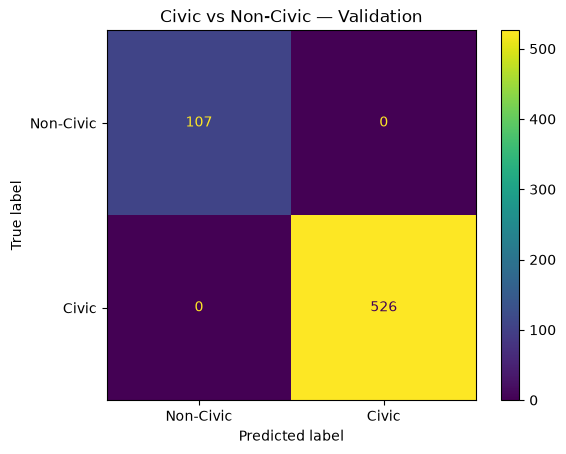

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred,
    display_labels=["Non-Civic", "Civic"]
)

plt.title("Civic vs Non-Civic — Validation")
plt.show()

In [23]:
y_test_pred = model.predict(X_test_tfidf)

print("Test Accuracy:",
      accuracy_score(y_test, y_test_pred))

print("\nTest Classification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Non-Civic", "Civic"]
    )
)

Test Accuracy: 1.0

Test Classification Report:
              precision    recall  f1-score   support

   Non-Civic       1.00      1.00      1.00       108
       Civic       1.00      1.00      1.00       525

    accuracy                           1.00       633
   macro avg       1.00      1.00      1.00       633
weighted avg       1.00      1.00      1.00       633



In [24]:
real_style_tests = [
    "There is a huge crater beside the school and motorcycles keep losing balance.",
    "The garbage truck has skipped our lane since Monday.",
    "Nobody has water in our apartment block since this morning.",
    "The drain behind the houses is filled with plastic and dirty water.",
    "The lamp on the road has been dead for several nights.",

    "My laptop won't boot after the latest update.",
    "I need help preparing for a coding interview.",
    "Can you suggest a good camera for travel?",
    "My headphones keep disconnecting from Bluetooth.",
    "Please explain binary search in simple terms."
]

# IMPORTANT: raw text -> TF-IDF
X_real = vectorizer.transform(real_style_tests)

# Prediction
pred = model.predict(X_real)

# Confidence
prob = model.predict_proba(X_real)

for text, p, confidence in zip(
    real_style_tests,
    pred,
    prob.max(axis=1)
):
    label = "Civic" if p == 1 else "Non-Civic"

    print(f"{confidence:.3f} | {label} | {text}")

0.876 | Civic | There is a huge crater beside the school and motorcycles keep losing balance.
0.810 | Civic | The garbage truck has skipped our lane since Monday.
0.723 | Civic | Nobody has water in our apartment block since this morning.
0.790 | Civic | The drain behind the houses is filled with plastic and dirty water.
0.854 | Civic | The lamp on the road has been dead for several nights.
0.756 | Non-Civic | My laptop won't boot after the latest update.
0.885 | Non-Civic | I need help preparing for a coding interview.
0.926 | Non-Civic | Can you suggest a good camera for travel?
0.837 | Non-Civic | My headphones keep disconnecting from Bluetooth.
0.817 | Non-Civic | Please explain binary search in simple terms.


In [25]:
y_test_pred = model.predict(X_test_tfidf)

print("Test Accuracy:",
      accuracy_score(y_test, y_test_pred))

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Non-Civic", "Civic"]
    )
)

Test Accuracy: 1.0
              precision    recall  f1-score   support

   Non-Civic       1.00      1.00      1.00       108
       Civic       1.00      1.00      1.00       525

    accuracy                           1.00       633
   macro avg       1.00      1.00      1.00       633
weighted avg       1.00      1.00      1.00       633



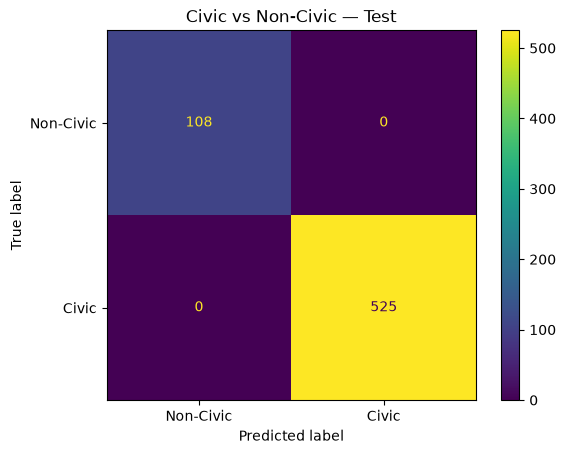

In [26]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Non-Civic", "Civic"]
)

plt.title("Civic vs Non-Civic — Test")
plt.show()

In [27]:
civic_df = df[df["is_civic"] == 1].copy()

print("Civic complaints:", len(civic_df))

print("\nArea distribution:")
print(civic_df["area"].value_counts())

Civic complaints: 3500

Area distribution:
area
Roads & Footpaths          280
Traffic & Road Safety      280
Waste Management           245
Water Supply               245
Sewerage & Drainage        245
Animal Issues              245
Pollution & Environment    245
Street Lighting            210
Public Transport           210
Trees & Greenery           210
Parks & Recreation         210
Public Sanitation          210
Public Safety              210
Public Infrastructure      210
Lakes & Water Bodies       210
Other Civic Issue           35
Name: count, dtype: int64


In [28]:
X_area = civic_df["complaint_text"]
y_area = civic_df["area"]

In [29]:
print("Number of areas:", y_area.nunique())
print("\nAreas:")
print(y_area.unique())

Number of areas: 16

Areas:
<StringArray>
[      'Roads & Footpaths',        'Waste Management',
            'Water Supply',     'Sewerage & Drainage',
         'Street Lighting',   'Traffic & Road Safety',
        'Public Transport',           'Animal Issues',
 'Pollution & Environment',        'Trees & Greenery',
      'Parks & Recreation',       'Public Sanitation',
           'Public Safety',   'Public Infrastructure',
    'Lakes & Water Bodies',       'Other Civic Issue']
Length: 16, dtype: str


In [30]:
from sklearn.model_selection import train_test_split

X_area = civic_df["complaint_text"]
y_area = civic_df["area"]

X_area_train, X_area_temp, y_area_train, y_area_temp = train_test_split(
    X_area,
    y_area,
    test_size=0.30,
    random_state=42,
    stratify=y_area
)

X_area_val, X_area_test, y_area_val, y_area_test = train_test_split(
    X_area_temp,
    y_area_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_area_temp
)

print("Train:", len(X_area_train))
print("Validation:", len(X_area_val))
print("Test:", len(X_area_test))

Train: 2450
Validation: 525
Test: 525


In [31]:
print("\nTrain distribution:")
print(y_area_train.value_counts())

print("\nValidation distribution:")
print(y_area_val.value_counts())

print("\nTest distribution:")
print(y_area_test.value_counts())


Train distribution:
area
Roads & Footpaths          196
Traffic & Road Safety      196
Sewerage & Drainage        172
Pollution & Environment    172
Water Supply               172
Animal Issues              171
Waste Management           171
Public Transport           147
Parks & Recreation         147
Public Safety              147
Lakes & Water Bodies       147
Public Infrastructure      147
Trees & Greenery           147
Street Lighting            147
Public Sanitation          147
Other Civic Issue           24
Name: count, dtype: int64

Validation distribution:
area
Roads & Footpaths          42
Traffic & Road Safety      42
Waste Management           37
Animal Issues              37
Sewerage & Drainage        37
Pollution & Environment    36
Water Supply               36
Lakes & Water Bodies       32
Parks & Recreation         32
Street Lighting            32
Trees & Greenery           32
Public Safety              32
Public Sanitation          31
Public Infrastructure      31
P

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

area_vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_area_train_tfidf = area_vectorizer.fit_transform(X_area_train)
X_area_val_tfidf = area_vectorizer.transform(X_area_val)
X_area_test_tfidf = area_vectorizer.transform(X_area_test)

print("Train shape:", X_area_train_tfidf.shape)
print("Validation shape:", X_area_val_tfidf.shape)
print("Test shape:", X_area_test_tfidf.shape)

print("Vocabulary size:", len(area_vectorizer.vocabulary_))

Train shape: (2450, 3647)
Validation shape: (525, 3647)
Test shape: (525, 3647)
Vocabulary size: 3647


In [33]:
from sklearn.linear_model import LogisticRegression

area_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

area_model.fit(
    X_area_train_tfidf,
    y_area_train
)

print("Area model trained successfully ✅")

Area model trained successfully ✅


In [34]:
from sklearn.metrics import accuracy_score, classification_report

y_area_val_pred = area_model.predict(X_area_val_tfidf)

print("Validation Accuracy:",
      accuracy_score(y_area_val, y_area_val_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_area_val,
        y_area_val_pred,
        zero_division=0
    )
)

Validation Accuracy: 0.9904761904761905

Classification Report:
                         precision    recall  f1-score   support

          Animal Issues       1.00      0.97      0.99        37
   Lakes & Water Bodies       1.00      1.00      1.00        32
      Other Civic Issue       1.00      1.00      1.00         5
     Parks & Recreation       1.00      1.00      1.00        32
Pollution & Environment       1.00      1.00      1.00        36
  Public Infrastructure       1.00      1.00      1.00        31
          Public Safety       0.97      1.00      0.98        32
      Public Sanitation       1.00      0.97      0.98        31
       Public Transport       1.00      1.00      1.00        31
      Roads & Footpaths       0.98      1.00      0.99        42
    Sewerage & Drainage       1.00      0.92      0.96        37
        Street Lighting       1.00      1.00      1.00        32
  Traffic & Road Safety       0.98      1.00      0.99        42
       Trees & Greenery  

<Figure size 1200x1000 with 0 Axes>

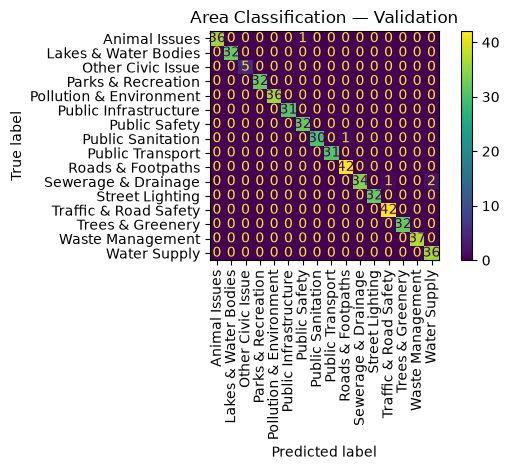

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_area_val,
    y_area_val_pred,
    xticks_rotation=90
)

plt.title("Area Classification — Validation")
plt.tight_layout()
plt.show()

In [36]:
y_area_test_pred = area_model.predict(X_area_test_tfidf)

print("Test Accuracy:",
      accuracy_score(y_area_test, y_area_test_pred))

print("\nTest Classification Report:")

print(
    classification_report(
        y_area_test,
        y_area_test_pred,
        zero_division=0
    )
)

Test Accuracy: 0.9828571428571429

Test Classification Report:
                         precision    recall  f1-score   support

          Animal Issues       1.00      1.00      1.00        37
   Lakes & Water Bodies       1.00      1.00      1.00        31
      Other Civic Issue       1.00      1.00      1.00         6
     Parks & Recreation       1.00      1.00      1.00        31
Pollution & Environment       0.95      1.00      0.97        37
  Public Infrastructure       1.00      1.00      1.00        32
          Public Safety       1.00      0.94      0.97        31
      Public Sanitation       1.00      0.88      0.93        32
       Public Transport       1.00      1.00      1.00        32
      Roads & Footpaths       0.91      1.00      0.95        42
    Sewerage & Drainage       1.00      0.92      0.96        36
        Street Lighting       1.00      1.00      1.00        31
  Traffic & Road Safety       0.98      1.00      0.99        42
       Trees & Greenery   

In [37]:
misclassified = civic_df.loc[
    X_area_val.index[
        y_area_val != y_area_val_pred
    ],
    ["complaint_text", "area", "sub_category"]
].copy()

misclassified["predicted_area"] = y_area_val_pred[
    y_area_val != y_area_val_pred
]

display(misclassified)

,complaint_text,area,sub_category,predicted_area
963,This location is experiencing wastewater cover...,Sewerage & Drainage,Wastewater on Road,Traffic & Road Safety
961,Please check dirty water pooling in the lane c...,Sewerage & Drainage,Wastewater on Road,Water Supply
977,There has been sewage water running along the ...,Sewerage & Drainage,Wastewater on Road,Water Supply
1846,A civic inspection is requested for a dog-bite...,Animal Issues,Animal Bite,Public Safety
2663,The problem involves repeated public urination...,Public Sanitation,Public Urination,Roads & Footpaths


In [38]:
real_world_area_tests = [
    "There is a huge pothole near the school and motorcycles are losing balance.",
    "A huge pile of garbage is blocking the road and traffic.",
    "Dirty contaminated water with a strong smell is coming from the taps.",
    "Sewage is overflowing onto the road near a hospital.",
    "The street light near my house has stopped working.",
    "A fallen tree is completely blocking the main road.",
    "There is loud construction noise disturbing the entire neighborhood every night.",
    "The park playground equipment is slightly damaged but still usable.",
    "There is an open manhole on a busy road.",
    "Several stray dogs are creating problems near our colony."
]

area_features = area_vectorizer.transform(real_world_area_tests)

area_predictions = area_model.predict(area_features)
area_probabilities = area_model.predict_proba(area_features)

for text, prediction, probability in zip(
    real_world_area_tests,
    area_predictions,
    area_probabilities
):
    print(
        f"{probability.max():.3f} | "
        f"{prediction} | "
        f"{text}"
    )

0.238 | Roads & Footpaths | There is a huge pothole near the school and motorcycles are losing balance.
0.301 | Traffic & Road Safety | A huge pile of garbage is blocking the road and traffic.
0.796 | Water Supply | Dirty contaminated water with a strong smell is coming from the taps.
0.378 | Sewerage & Drainage | Sewage is overflowing onto the road near a hospital.
0.778 | Street Lighting | The street light near my house has stopped working.
0.615 | Trees & Greenery | A fallen tree is completely blocking the main road.
0.327 | Pollution & Environment | There is loud construction noise disturbing the entire neighborhood every night.
0.749 | Parks & Recreation | The park playground equipment is slightly damaged but still usable.
0.269 | Sewerage & Drainage | There is an open manhole on a busy road.
0.724 | Animal Issues | Several stray dogs are creating problems near our colony.


In [39]:
y_area_test_pred = area_model.predict(X_area_test_tfidf)

print("Area Test Accuracy:",
      accuracy_score(y_area_test, y_area_test_pred))

print("\nTest Classification Report:")
print(
    classification_report(
        y_area_test,
        y_area_test_pred,
        zero_division=0
    )
)

Area Test Accuracy: 0.9828571428571429

Test Classification Report:
                         precision    recall  f1-score   support

          Animal Issues       1.00      1.00      1.00        37
   Lakes & Water Bodies       1.00      1.00      1.00        31
      Other Civic Issue       1.00      1.00      1.00         6
     Parks & Recreation       1.00      1.00      1.00        31
Pollution & Environment       0.95      1.00      0.97        37
  Public Infrastructure       1.00      1.00      1.00        32
          Public Safety       1.00      0.94      0.97        31
      Public Sanitation       1.00      0.88      0.93        32
       Public Transport       1.00      1.00      1.00        32
      Roads & Footpaths       0.91      1.00      0.95        42
    Sewerage & Drainage       1.00      0.92      0.96        36
        Street Lighting       1.00      1.00      1.00        31
  Traffic & Road Safety       0.98      1.00      0.99        42
       Trees & Greene

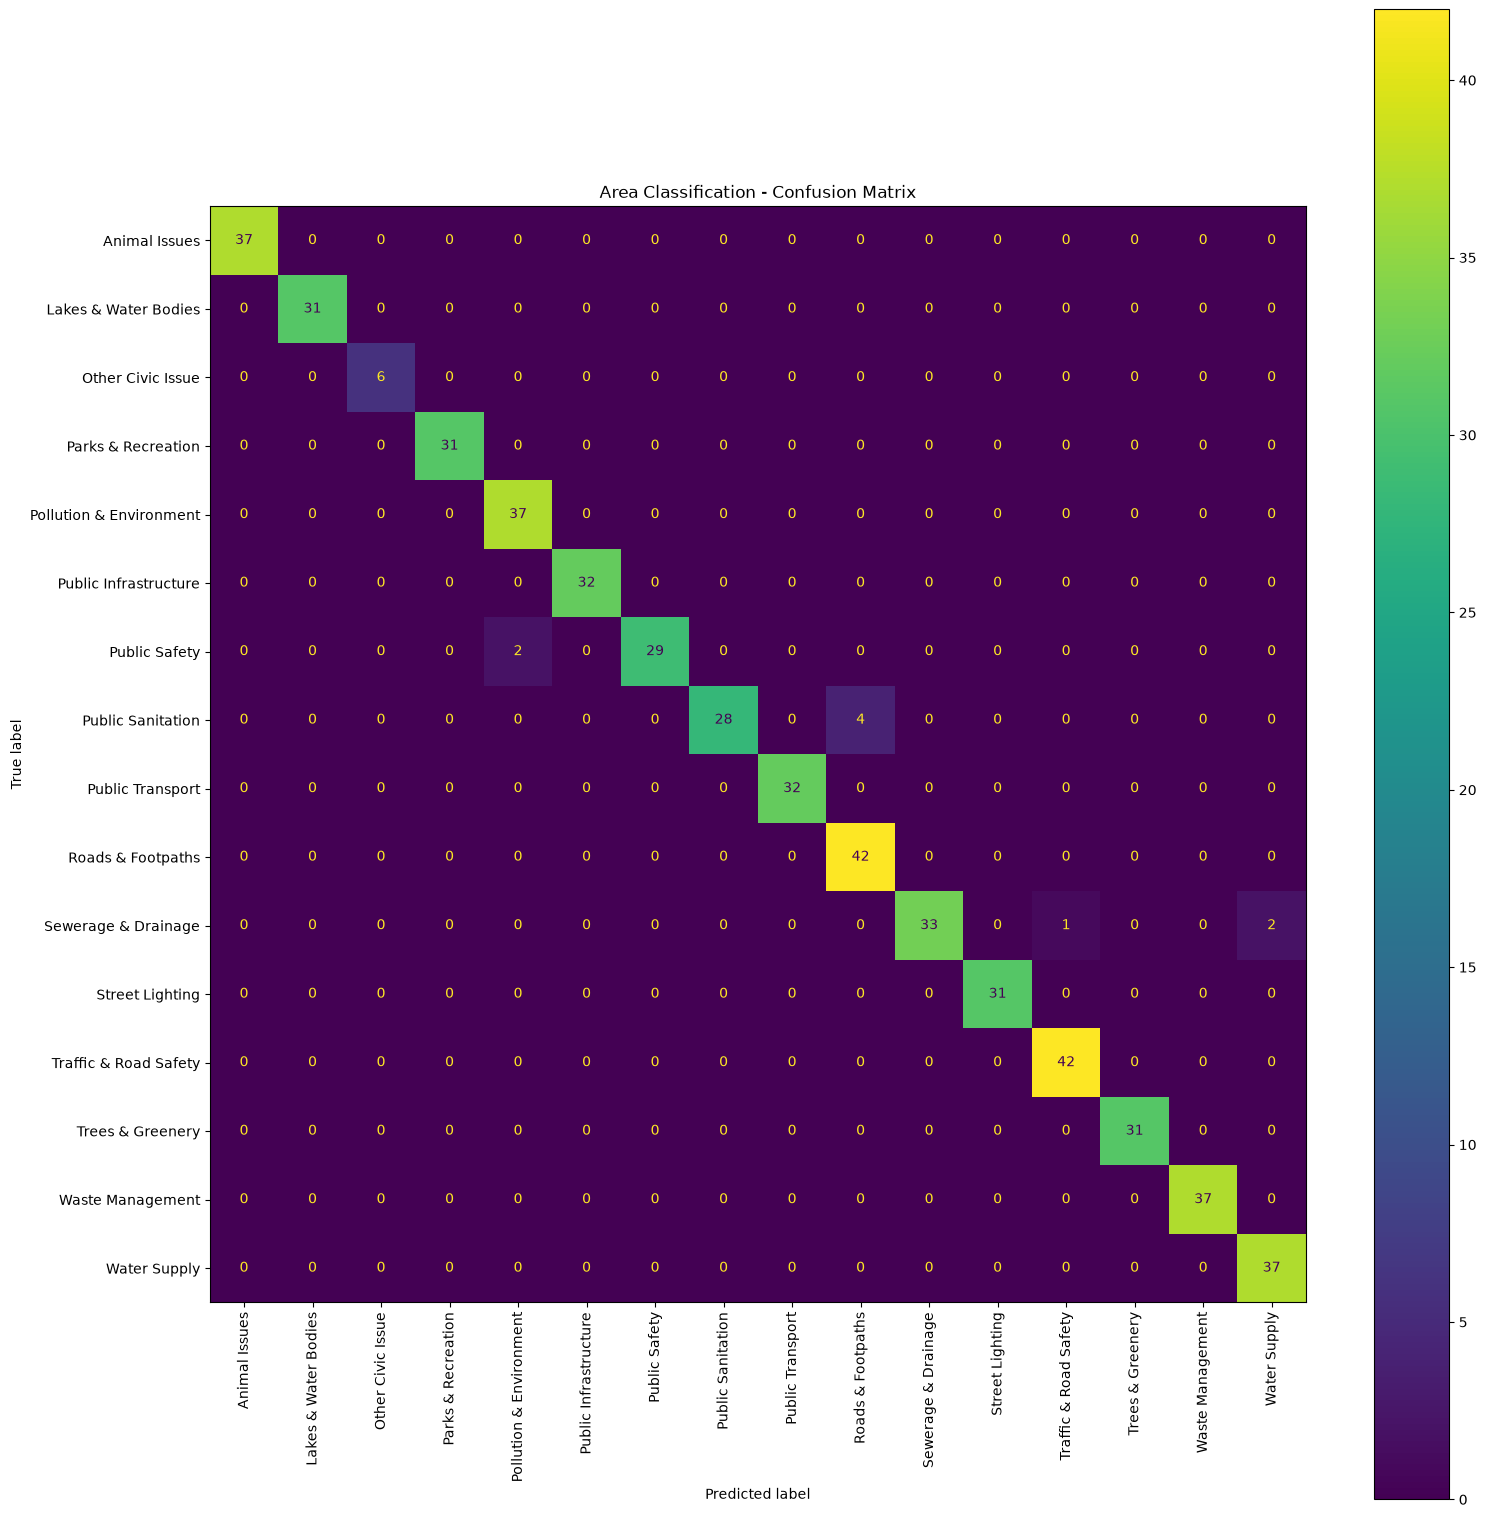

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_area_test,
    y_area_test_pred,
    labels=area_model.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=area_model.classes_
)

fig, ax = plt.subplots(figsize=(16, 16))
disp.plot(ax=ax, xticks_rotation=90)
plt.title("Area Classification - Confusion Matrix")
plt.tight_layout()
plt.show()

In [41]:
roads_df = civic_df[
    civic_df["area"] == "Roads & Footpaths"
].copy()

print("Road complaints:", len(roads_df))

print("\nRoad sub-categories:")
print(roads_df["sub_category"].value_counts())

Road complaints: 280

Road sub-categories:
sub_category
Pothole                          35
Damaged Road                     35
Broken Footpath                  35
Missing Footpath                 35
Road Construction/Maintenance    35
Road Obstruction                 35
Road Signage                     35
Road Encroachment                35
Name: count, dtype: int64


In [42]:
from sklearn.model_selection import train_test_split

X_road = roads_df["complaint_text"]
y_road = roads_df["sub_category"]

X_road_train, X_road_temp, y_road_train, y_road_temp = train_test_split(
    X_road,
    y_road,
    test_size=0.30,
    random_state=42,
    stratify=y_road
)

X_road_val, X_road_test, y_road_val, y_road_test = train_test_split(
    X_road_temp,
    y_road_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_road_temp
)

print("Train:", len(X_road_train))
print("Validation:", len(X_road_val))
print("Test:", len(X_road_test))

Train: 196
Validation: 42
Test: 42


In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

road_vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

X_road_train_tfidf = road_vectorizer.fit_transform(X_road_train)
X_road_val_tfidf = road_vectorizer.transform(X_road_val)
X_road_test_tfidf = road_vectorizer.transform(X_road_test)

print("Train shape:", X_road_train_tfidf.shape)
print("Validation shape:", X_road_val_tfidf.shape)
print("Test shape:", X_road_test_tfidf.shape)
print("Vocabulary:", len(road_vectorizer.vocabulary_))

Train shape: (196, 799)
Validation shape: (42, 799)
Test shape: (42, 799)
Vocabulary: 799


In [44]:
from sklearn.linear_model import LogisticRegression

road_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

road_model.fit(
    X_road_train_tfidf,
    y_road_train
)

print("Road sub-category model trained successfully ✅")

Road sub-category model trained successfully ✅


In [45]:
from sklearn.metrics import accuracy_score, classification_report

y_road_val_pred = road_model.predict(X_road_val_tfidf)

print("Validation Accuracy:",
      accuracy_score(y_road_val, y_road_val_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_road_val,
        y_road_val_pred,
        zero_division=0
    )
)

Validation Accuracy: 0.9523809523809523

Classification Report:
                               precision    recall  f1-score   support

              Broken Footpath       1.00      0.60      0.75         5
                 Damaged Road       1.00      1.00      1.00         5
             Missing Footpath       1.00      1.00      1.00         5
                      Pothole       0.75      1.00      0.86         6
Road Construction/Maintenance       1.00      1.00      1.00         5
            Road Encroachment       1.00      1.00      1.00         5
             Road Obstruction       1.00      1.00      1.00         6
                 Road Signage       1.00      1.00      1.00         5

                     accuracy                           0.95        42
                    macro avg       0.97      0.95      0.95        42
                 weighted avg       0.96      0.95      0.95        42



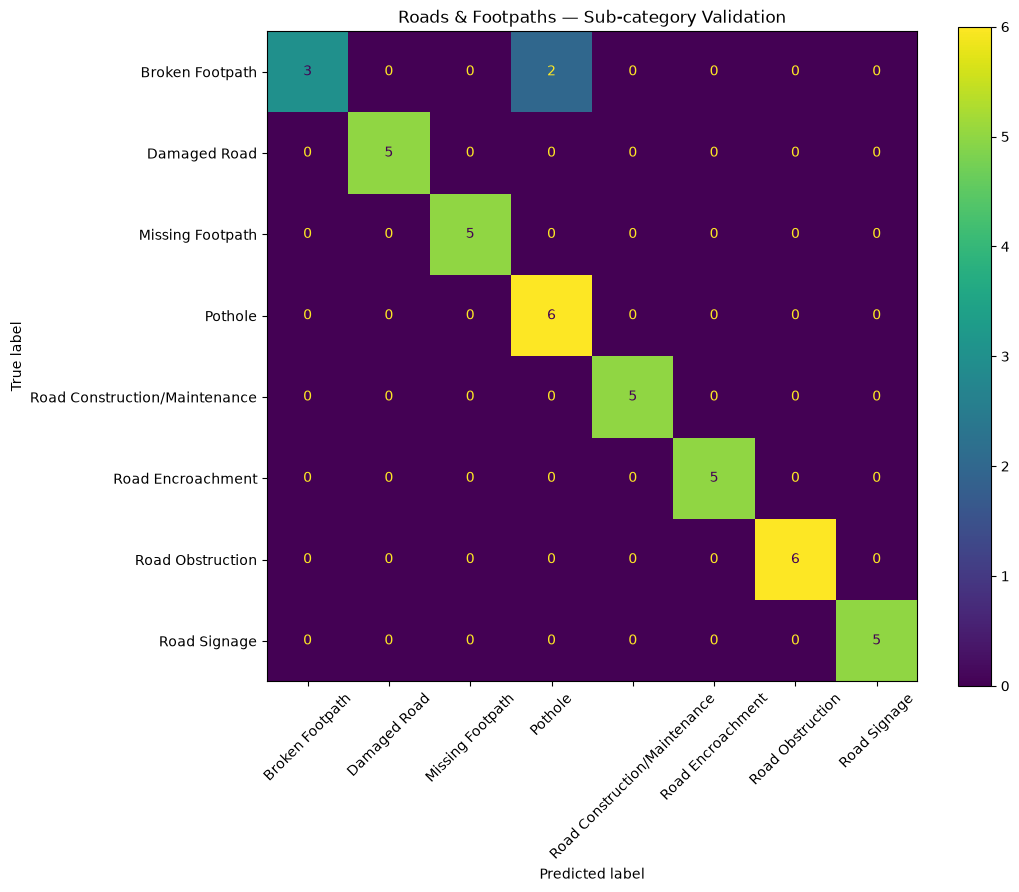

In [46]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 9))

ConfusionMatrixDisplay.from_predictions(
    y_road_val,
    y_road_val_pred,
    xticks_rotation=45,
    ax=ax
)

ax.set_title("Roads & Footpaths — Sub-category Validation")
plt.tight_layout()
plt.show()

In [47]:
y_road_test_pred = road_model.predict(X_road_test_tfidf)

print("Test Accuracy:",
      accuracy_score(y_road_test, y_road_test_pred))

print("\nTest Classification Report:")
print(
    classification_report(
        y_road_test,
        y_road_test_pred,
        zero_division=0
    )
)

Test Accuracy: 0.9761904761904762

Test Classification Report:
                               precision    recall  f1-score   support

              Broken Footpath       1.00      0.80      0.89         5
                 Damaged Road       1.00      1.00      1.00         5
             Missing Footpath       1.00      1.00      1.00         6
                      Pothole       0.83      1.00      0.91         5
Road Construction/Maintenance       1.00      1.00      1.00         6
            Road Encroachment       1.00      1.00      1.00         5
             Road Obstruction       1.00      1.00      1.00         5
                 Road Signage       1.00      1.00      1.00         5

                     accuracy                           0.98        42
                    macro avg       0.98      0.97      0.97        42
                 weighted avg       0.98      0.98      0.98        42



In [48]:
y_road_test_pred = road_model.predict(X_road_test_tfidf)

print("Test Accuracy:",
      accuracy_score(y_road_test, y_road_test_pred))

print("\nTest Classification Report:")
print(
    classification_report(
        y_road_test,
        y_road_test_pred,
        zero_division=0
    )
)

Test Accuracy: 0.9761904761904762

Test Classification Report:
                               precision    recall  f1-score   support

              Broken Footpath       1.00      0.80      0.89         5
                 Damaged Road       1.00      1.00      1.00         5
             Missing Footpath       1.00      1.00      1.00         6
                      Pothole       0.83      1.00      0.91         5
Road Construction/Maintenance       1.00      1.00      1.00         6
            Road Encroachment       1.00      1.00      1.00         5
             Road Obstruction       1.00      1.00      1.00         5
                 Road Signage       1.00      1.00      1.00         5

                     accuracy                           0.98        42
                    macro avg       0.98      0.97      0.97        42
                 weighted avg       0.98      0.98      0.98        42



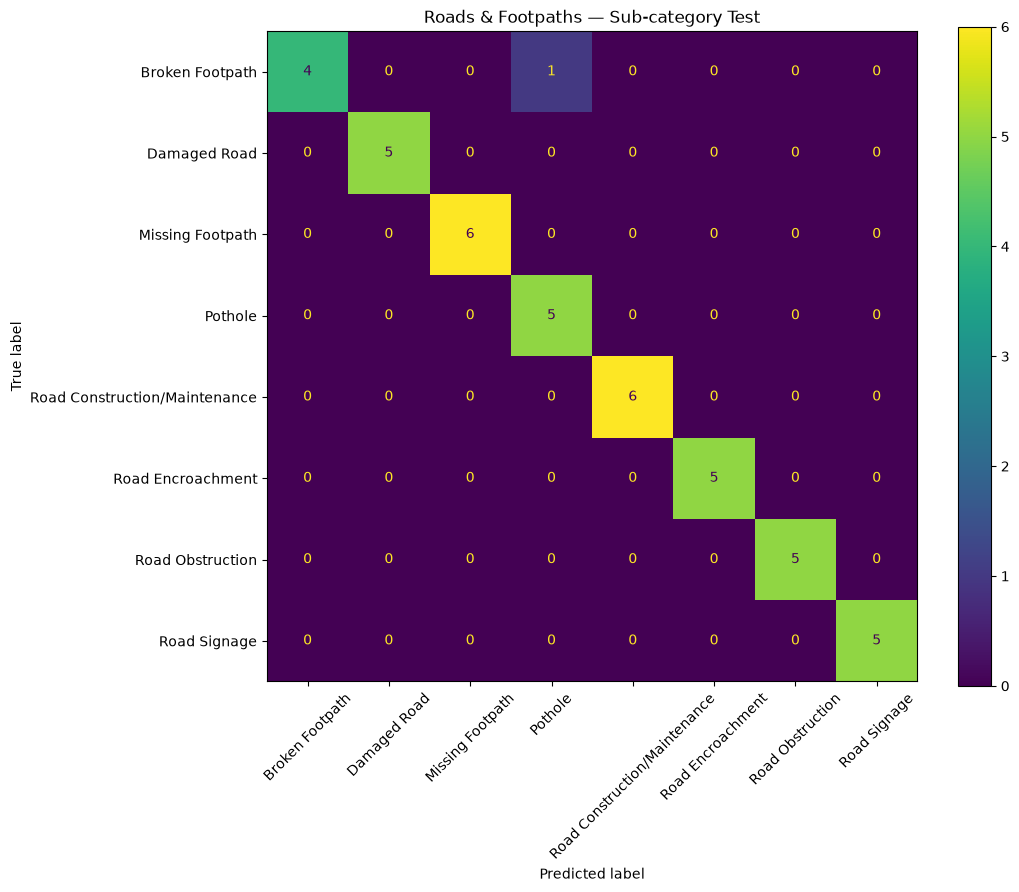

In [49]:
fig, ax = plt.subplots(figsize=(11, 9))

ConfusionMatrixDisplay.from_predictions(
    y_road_test,
    y_road_test_pred,
    xticks_rotation=45,
    ax=ax
)

ax.set_title("Roads & Footpaths — Sub-category Test")
plt.tight_layout()
plt.show()

In [50]:
subcat_df = df[df["is_civic"] == 1].copy()

X_sub = subcat_df["complaint_text"]
y_sub = subcat_df["sub_category"]

print("Total civic complaints:", len(subcat_df))
print("Number of sub-categories:", y_sub.nunique())

print("\nSub-category distribution:")
print(y_sub.value_counts().head(20))

Total civic complaints: 3500
Number of sub-categories: 100

Sub-category distribution:
sub_category
Pothole                           35
Damaged Road                      35
Broken Footpath                   35
Missing Footpath                  35
Road Construction/Maintenance     35
Road Obstruction                  35
Road Signage                      35
Road Encroachment                 35
Garbage Not Collected             35
Illegal Garbage Dumping           35
Overflowing Dustbin               35
Littering                         35
Construction Waste                35
Garbage Burning                   35
Waste Collection Vehicle Issue    35
No Water Supply                   35
Water Leakage                     35
Pipeline Damage                   35
Low Water Pressure                35
Contaminated Water                35
Name: count, dtype: int64


In [51]:
from sklearn.model_selection import train_test_split

X_sub_train, X_sub_temp, y_sub_train, y_sub_temp = train_test_split(
    X_sub,
    y_sub,
    test_size=0.30,
    random_state=42,
    stratify=y_sub
)

X_sub_val, X_sub_test, y_sub_val, y_sub_test = train_test_split(
    X_sub_temp,
    y_sub_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_sub_temp
)

print("Train:", len(X_sub_train))
print("Validation:", len(X_sub_val))
print("Test:", len(X_sub_test))

Train: 2450
Validation: 525
Test: 525


In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer

sub_vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

X_sub_train_tfidf = sub_vectorizer.fit_transform(X_sub_train)
X_sub_val_tfidf = sub_vectorizer.transform(X_sub_val)
X_sub_test_tfidf = sub_vectorizer.transform(X_sub_test)

print("Train shape:", X_sub_train_tfidf.shape)
print("Validation shape:", X_sub_val_tfidf.shape)
print("Test shape:", X_sub_test_tfidf.shape)
print("Vocabulary:", len(sub_vectorizer.vocabulary_))

Train shape: (2450, 4227)
Validation shape: (525, 4227)
Test shape: (525, 4227)
Vocabulary: 4227


In [53]:
from sklearn.linear_model import LogisticRegression

sub_model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    random_state=42
)

sub_model.fit(
    X_sub_train_tfidf,
    y_sub_train
)

print("100-class Sub-category model trained successfully ✅")

100-class Sub-category model trained successfully ✅


In [54]:
from sklearn.metrics import accuracy_score, classification_report

y_sub_val_pred = sub_model.predict(X_sub_val_tfidf)

print(
    "Validation Accuracy:",
    accuracy_score(y_sub_val, y_sub_val_pred)
)

print("\nClassification Report:")
print(
    classification_report(
        y_sub_val,
        y_sub_val_pred,
        zero_division=0
    )
)

Validation Accuracy: 0.9809523809523809

Classification Report:
                                    precision    recall  f1-score   support

          Accessibility/Ramp Issue       1.00      1.00      1.00         5
                     Air Pollution       1.00      1.00      1.00         5
                       Animal Bite       1.00      1.00      1.00         5
                   Animal Nuisance       1.00      1.00      1.00         5
                     Animal Rescue       1.00      1.00      1.00         5
              Animal Sterilization       1.00      1.00      1.00         5
                     Blocked Sewer       1.00      1.00      1.00         6
                   Broken Footpath       1.00      1.00      1.00         5
                  Bus Overcrowding       1.00      1.00      1.00         6
                   Bus Route Issue       1.00      1.00      1.00         5
                 Bus Service Issue       1.00      1.00      1.00         5
                    Bus

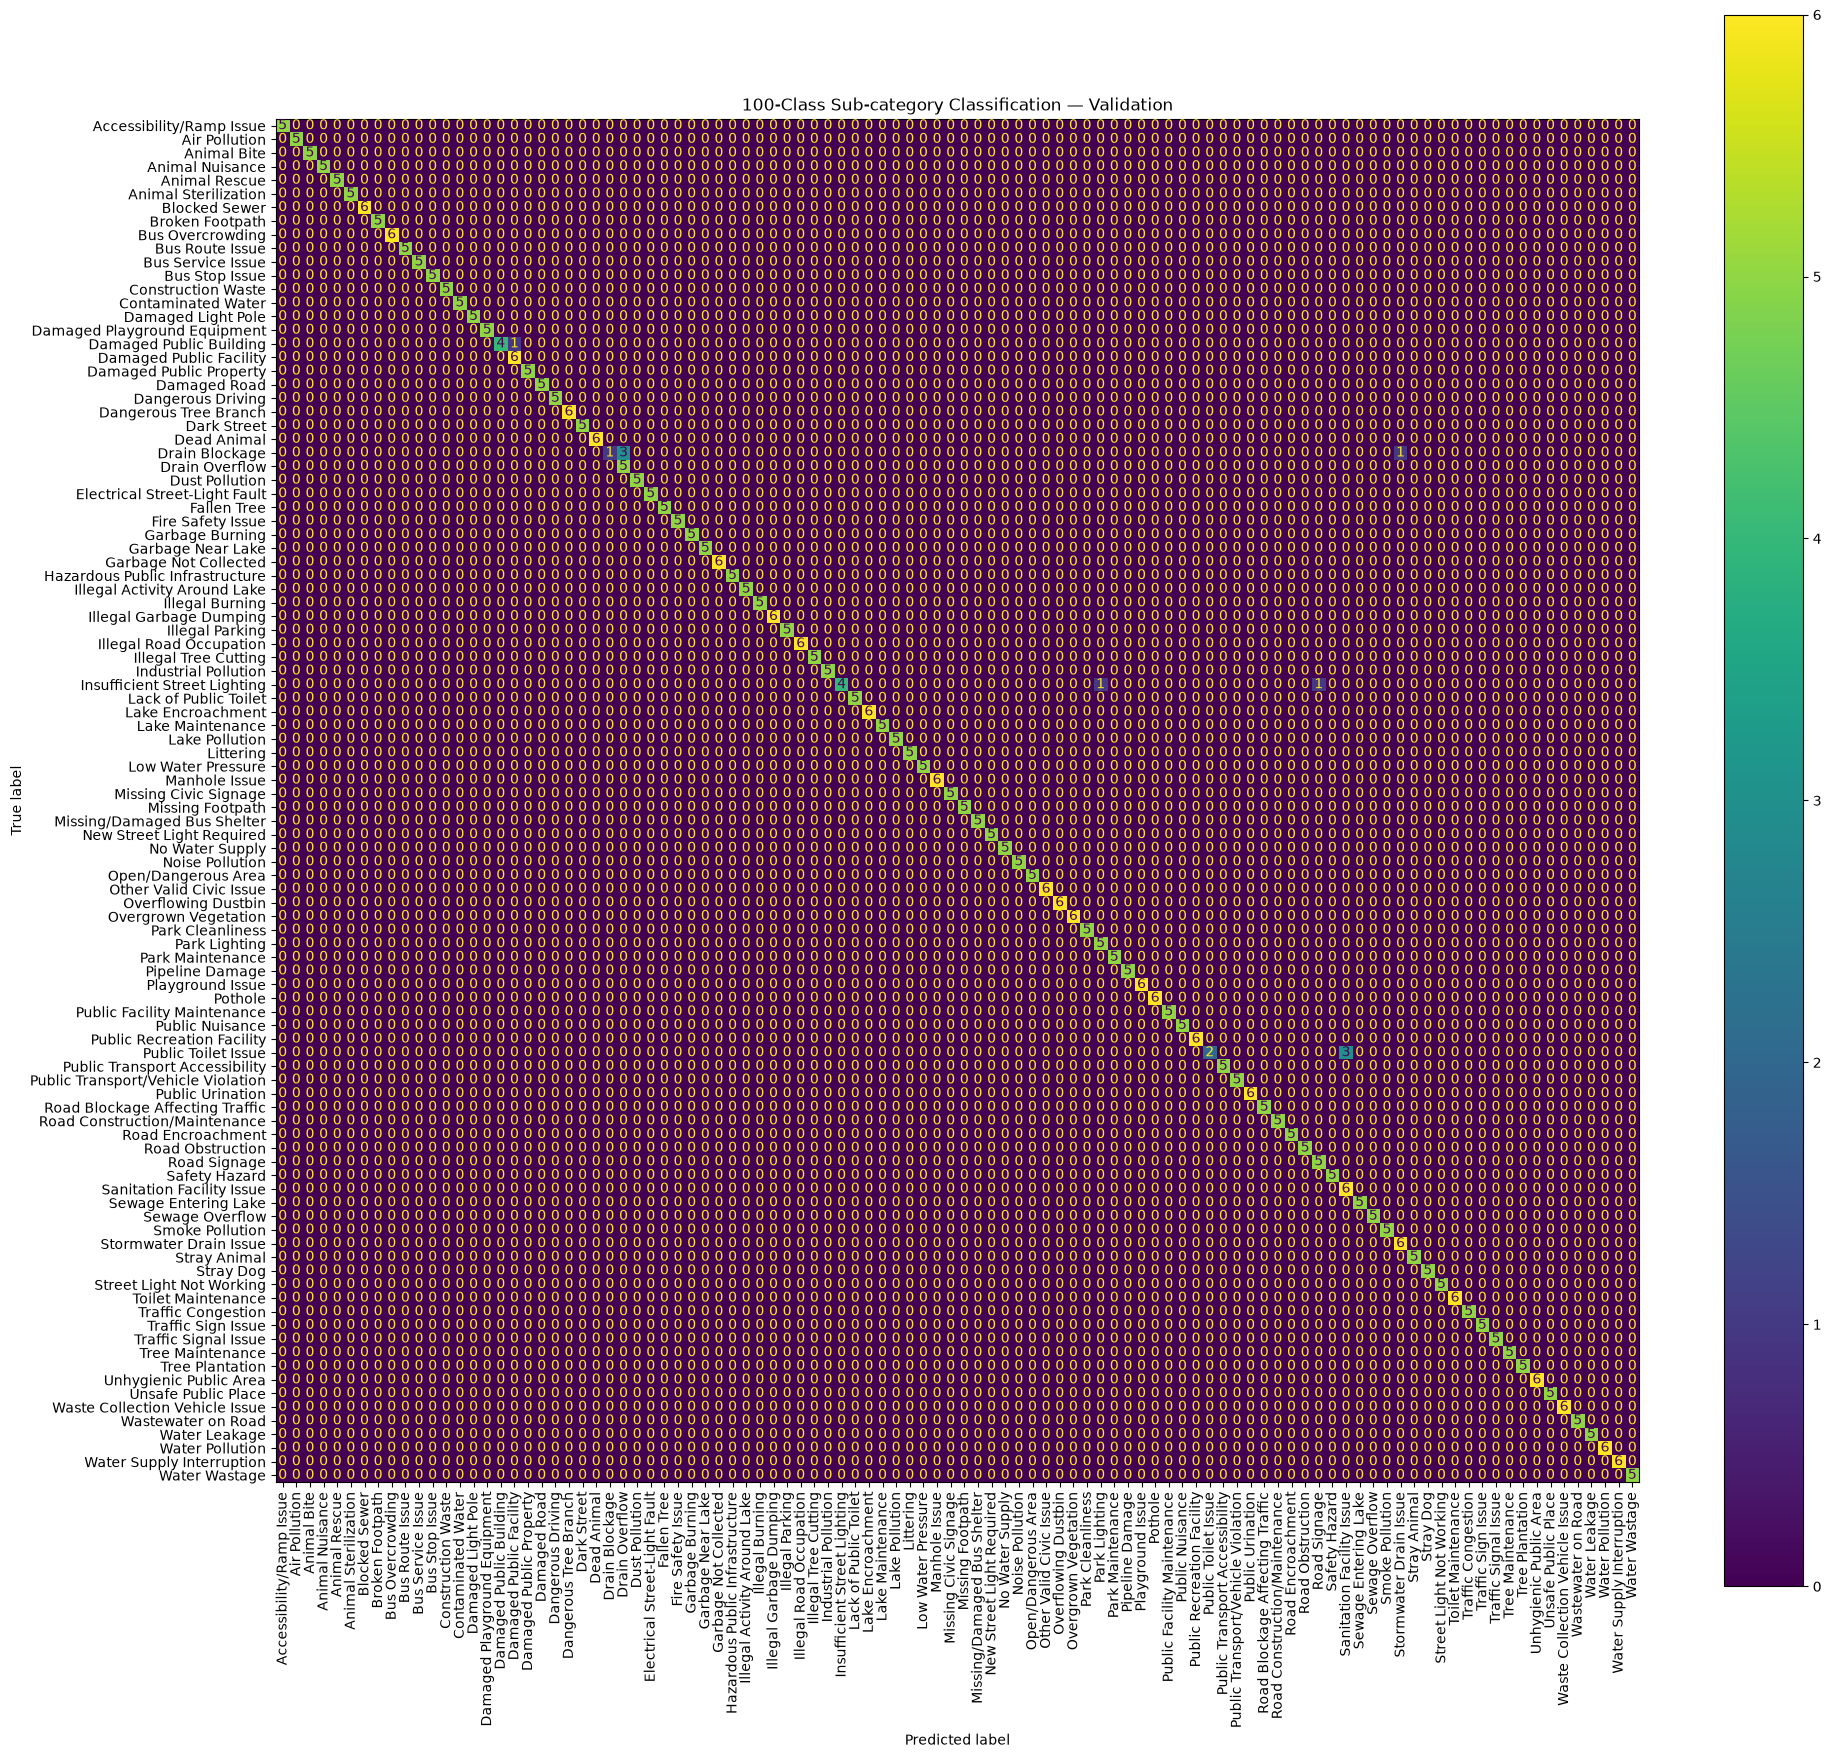

In [55]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(20, 18))

ConfusionMatrixDisplay.from_predictions(
    y_sub_val,
    y_sub_val_pred,
    xticks_rotation=90,
    ax=ax
)

ax.set_title("100-Class Sub-category Classification — Validation")
plt.tight_layout()
plt.show()

In [56]:
mis_sub = subcat_df.loc[
    X_sub_val.index[y_sub_val != y_sub_val_pred],
    ["complaint_text", "area", "sub_category"]
].copy()

mis_sub["predicted_sub_category"] = y_sub_val_pred[
    y_sub_val != y_sub_val_pred
]

display(mis_sub)

,complaint_text,area,sub_category,predicted_sub_category
1129,Residents are asking the civic team to inspect...,Street Lighting,Insufficient Street Lighting,Road Signage
855,Local commuters say they are facing a blocked ...,Sewerage & Drainage,Drain Blockage,Stormwater Drain Issue
2659,There is a public sanitation facility needing ...,Public Sanitation,Public Toilet Issue,Sanitation Facility Issue
2639,There is a public sanitation facility needing ...,Public Sanitation,Public Toilet Issue,Sanitation Facility Issue
3059,There is a damaged government facility near th...,Public Infrastructure,Damaged Public Building,Damaged Public Facility
850,People using the area have pointed out a block...,Sewerage & Drainage,Drain Blockage,Drain Overflow
1154,There is insufficient lighting around the junc...,Street Lighting,Insufficient Street Lighting,Park Lighting
870,People using the area have pointed out a block...,Sewerage & Drainage,Drain Blockage,Drain Overflow
845,Residents say the situation around the locatio...,Sewerage & Drainage,Drain Blockage,Drain Overflow
2629,The civic issue was noticed along the highway-...,Public Sanitation,Public Toilet Issue,Sanitation Facility Issue


In [57]:
y_sub_test_pred = sub_model.predict(X_sub_test_tfidf)

print("Sub-category Test Accuracy:",
      accuracy_score(y_sub_test, y_sub_test_pred))

print("\nTest Classification Report:")
print(
    classification_report(
        y_sub_test,
        y_sub_test_pred,
        zero_division=0
    )
)

Sub-category Test Accuracy: 0.9752380952380952

Test Classification Report:
                                    precision    recall  f1-score   support

          Accessibility/Ramp Issue       1.00      1.00      1.00         5
                     Air Pollution       1.00      1.00      1.00         6
                       Animal Bite       1.00      1.00      1.00         6
                   Animal Nuisance       1.00      0.83      0.91         6
                     Animal Rescue       1.00      1.00      1.00         5
              Animal Sterilization       1.00      1.00      1.00         5
                     Blocked Sewer       1.00      1.00      1.00         5
                   Broken Footpath       1.00      1.00      1.00         5
                  Bus Overcrowding       1.00      1.00      1.00         5
                   Bus Route Issue       1.00      1.00      1.00         5
                 Bus Service Issue       1.00      1.00      1.00         5
           

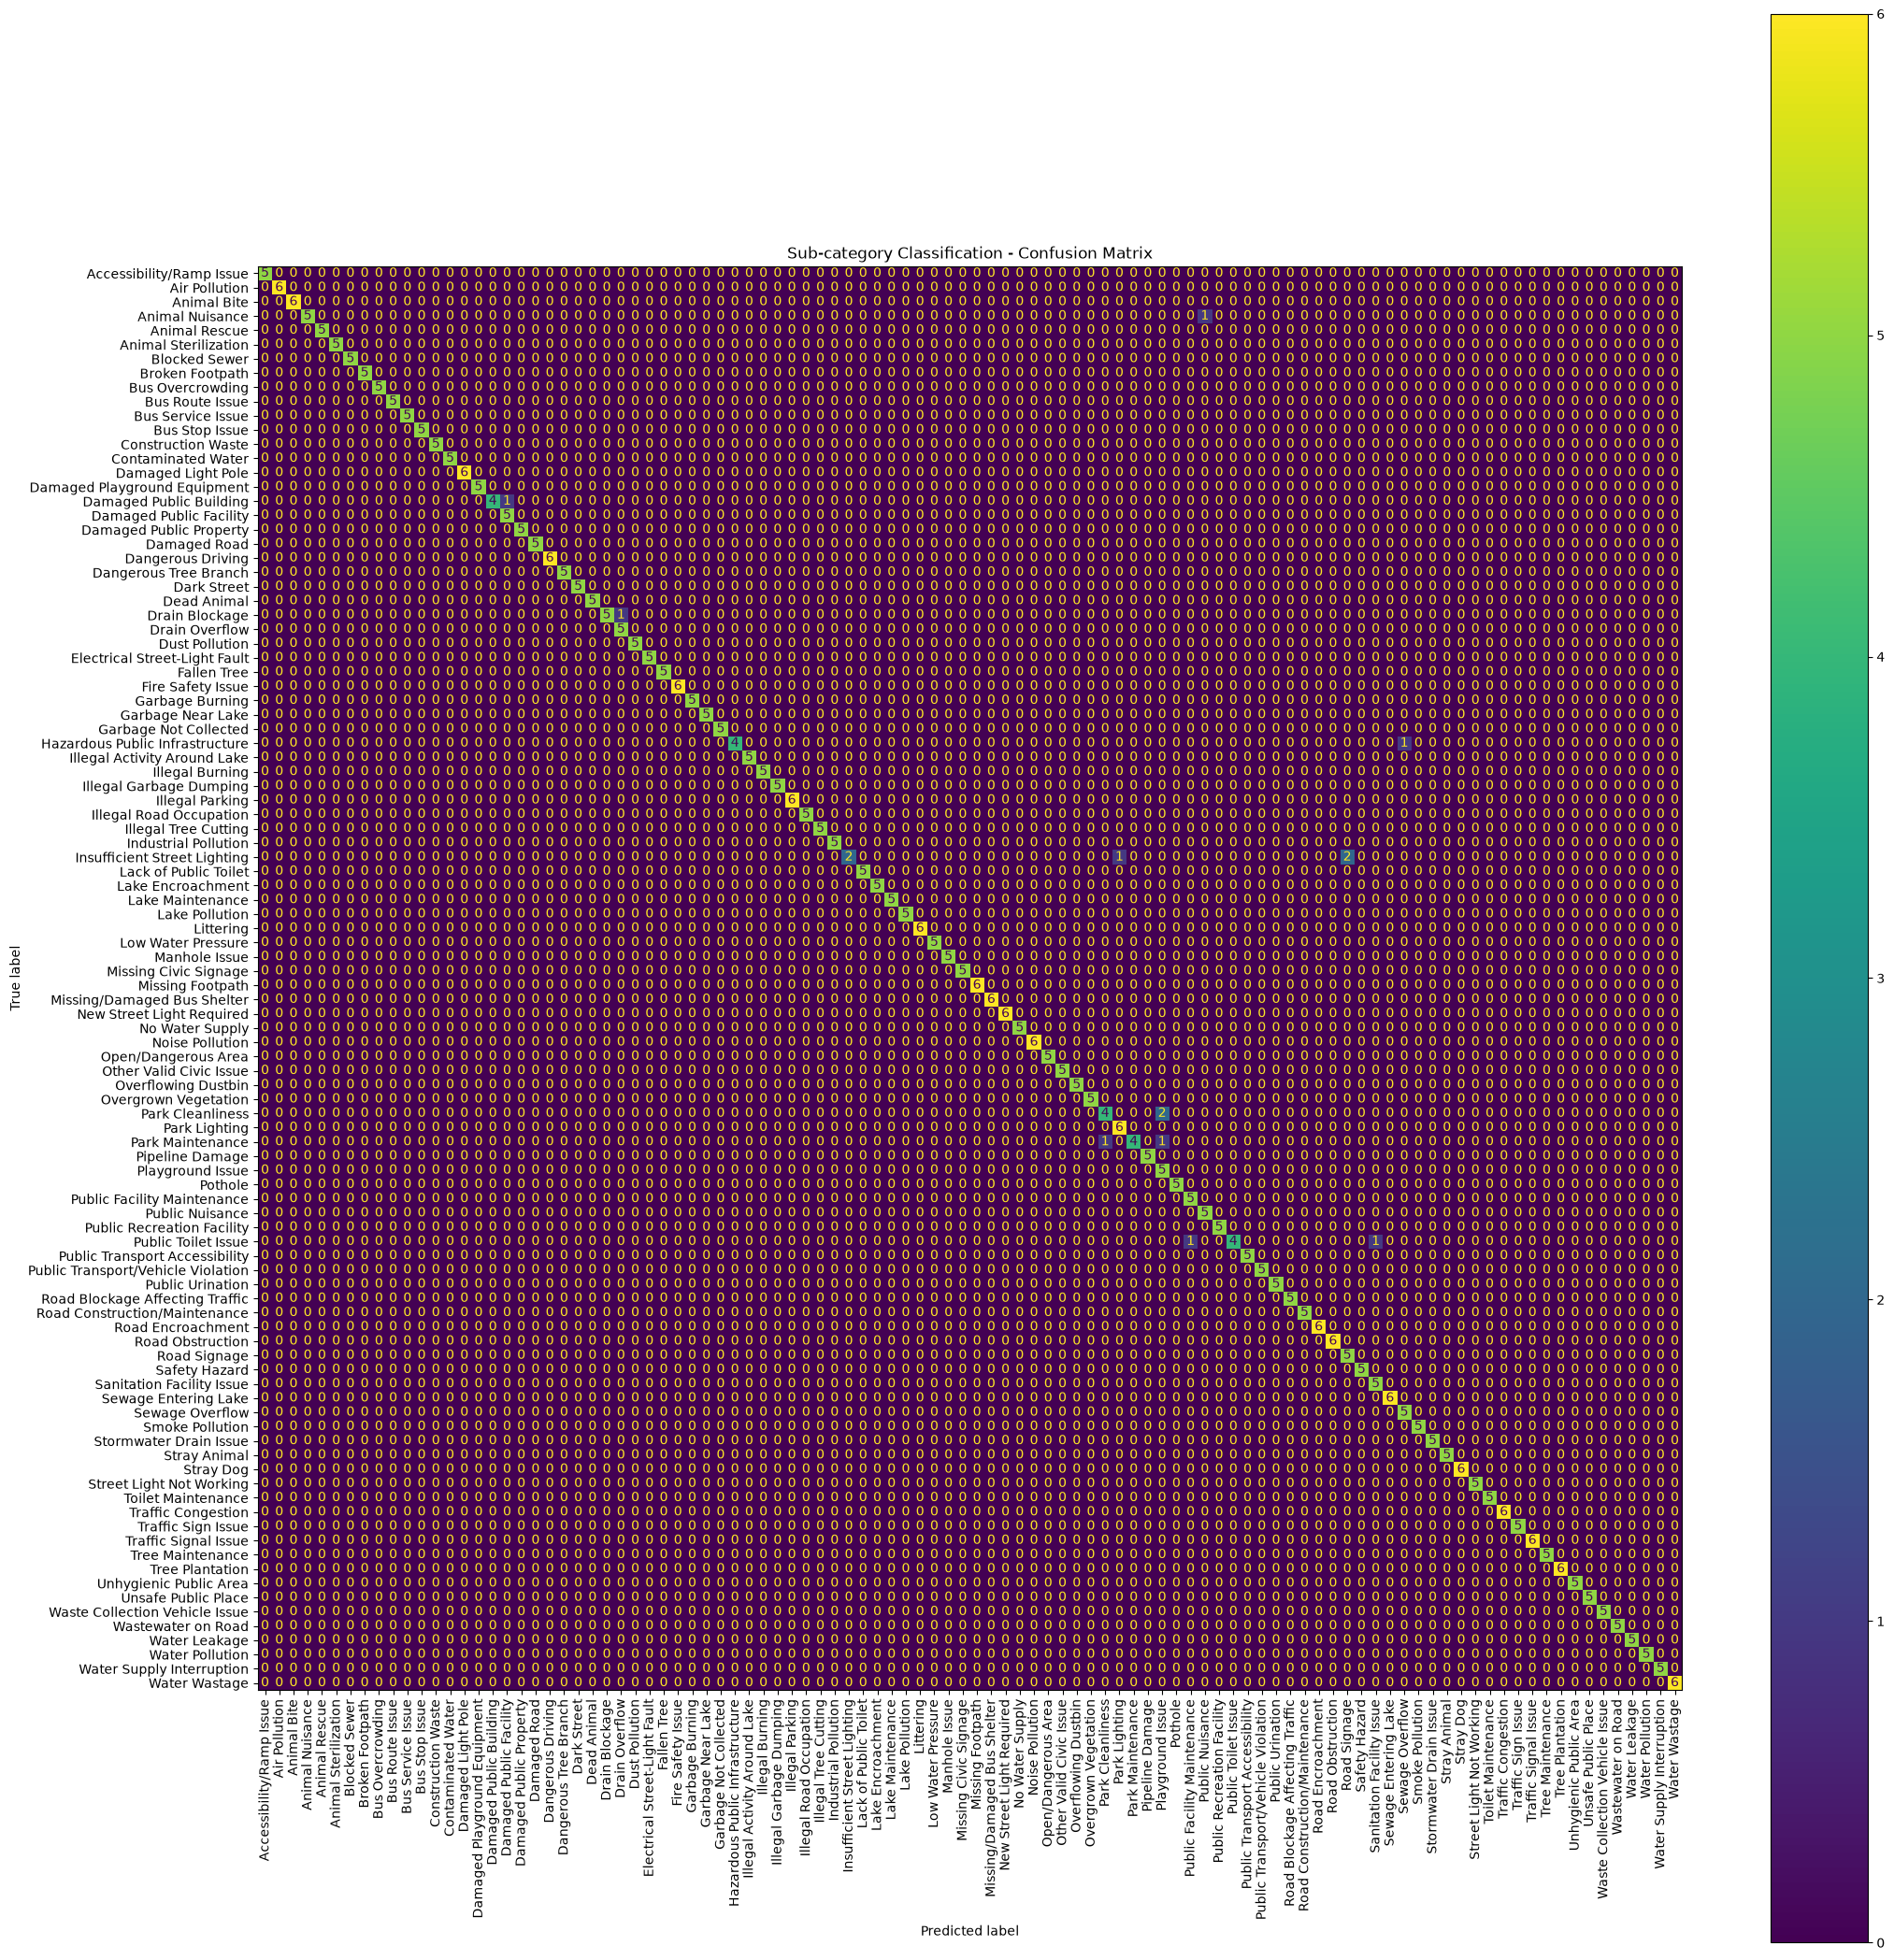

In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_sub_test,
    y_sub_test_pred,
    labels=sub_model.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sub_model.classes_
)

fig, ax = plt.subplots(figsize=(22, 22))

disp.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d"
)

plt.title("Sub-category Classification - Confusion Matrix")
plt.tight_layout()
plt.show()

In [59]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Train and test text
train_texts = X_sub_train.tolist()
test_texts = X_sub_test.tolist()

# TF-IDF only for similarity analysis
sim_vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=1
)

train_matrix = sim_vectorizer.fit_transform(train_texts)
test_matrix = sim_vectorizer.transform(test_texts)

# For every test complaint, find most similar training complaint
similarities = cosine_similarity(test_matrix, train_matrix)

max_similarities = similarities.max(axis=1)

print("Average max similarity:",
      max_similarities.mean())

print("Median max similarity:",
      np.median(max_similarities))

print("Minimum max similarity:",
      max_similarities.min())

print("Maximum max similarity:",
      max_similarities.max())

print("\nHighly similar test samples:")
print(
    np.sum(max_similarities >= 0.80),
    "out of",
    len(max_similarities)
)

Average max similarity: 0.762840642687603
Median max similarity: 0.7761711986418747
Minimum max similarity: 0.45137533582554046
Maximum max similarity: 0.9625303911696381

Highly similar test samples:
194 out of 525


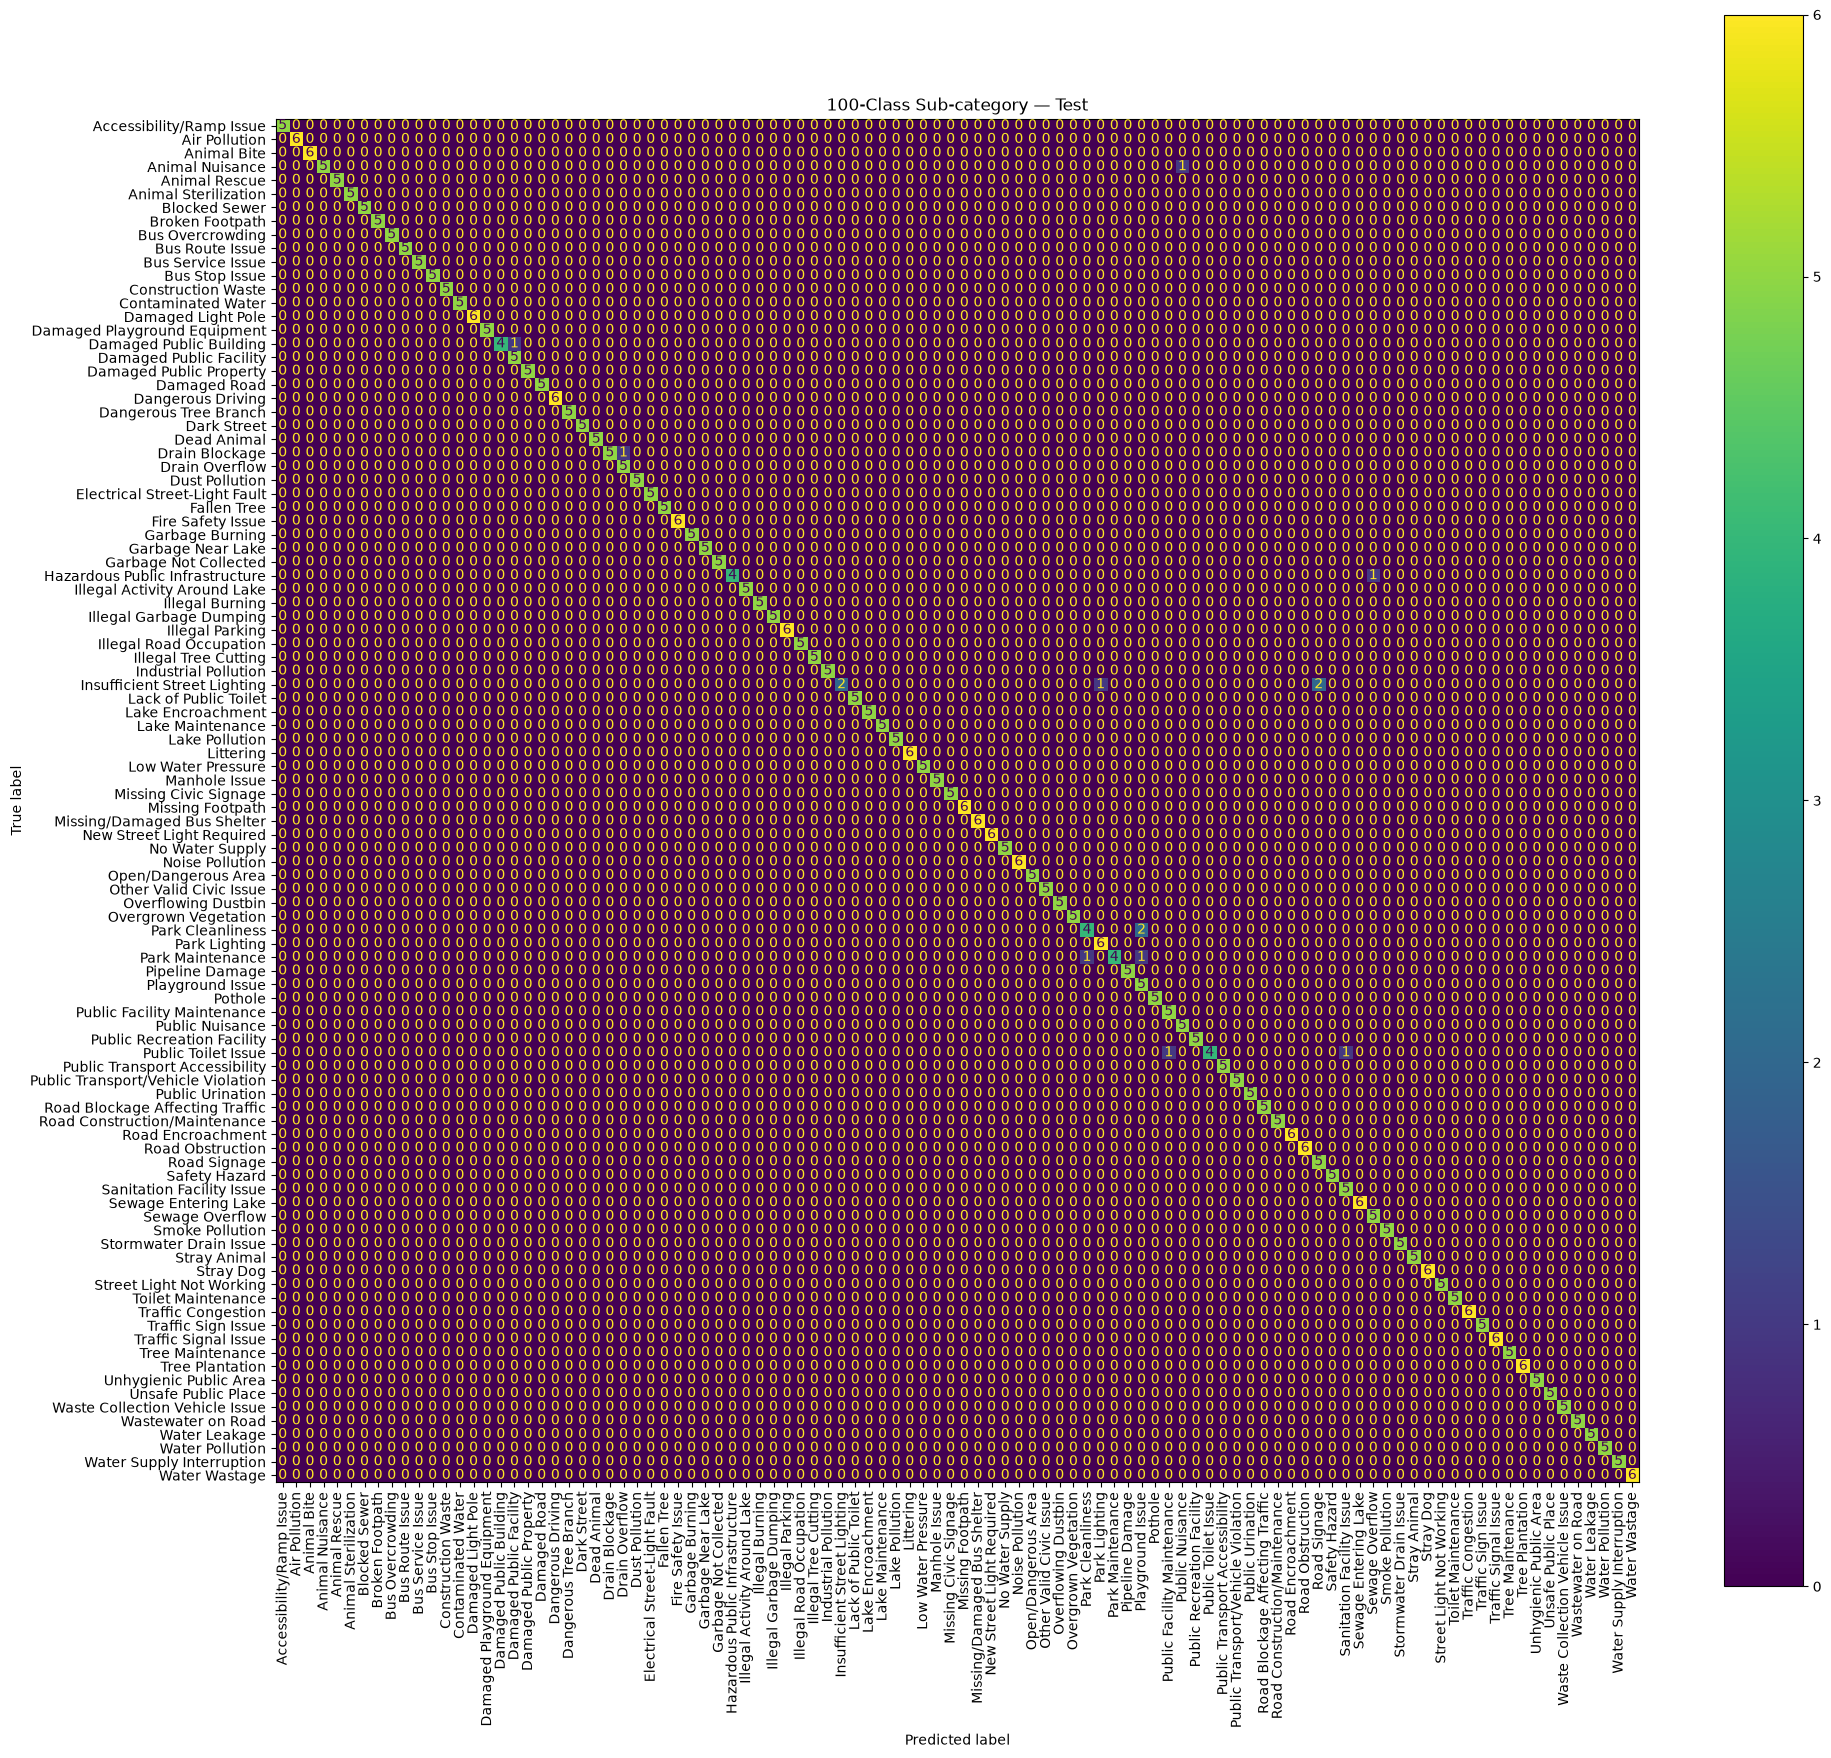

In [60]:
fig, ax = plt.subplots(figsize=(20, 18))

ConfusionMatrixDisplay.from_predictions(
    y_sub_test,
    y_sub_test_pred,
    xticks_rotation=90,
    ax=ax
)

ax.set_title("100-Class Sub-category — Test")
plt.tight_layout()
plt.show()

In [61]:
# Top 20 most similar train-test pairs

top_k = 20

flat_indices = np.argsort(
    similarities.ravel()
)[-top_k:][::-1]

for rank, flat_idx in enumerate(flat_indices, start=1):

    test_idx, train_idx = np.unravel_index(
        flat_idx,
        similarities.shape
    )

    score = similarities[test_idx, train_idx]

    print(f"\n{'='*80}")
    print(f"Rank: {rank}")
    print(f"Similarity: {score:.3f}")

    print("\nTEST:")
    print(test_texts[test_idx])

    print("\nTRAIN:")
    print(train_texts[train_idx])


Rank: 1
Similarity: 0.963

TEST:
Residents are asking the civic team to inspect a lane blocked by parked or abandoned material near the college entrance on most weekdays. Residents are facing minor inconvenience.

TRAIN:
Residents are asking the civic team to inspect a lane blocked by parked or abandoned material near the colony entrance on most weekdays. Residents are facing minor inconvenience.

Rank: 2
Similarity: 0.959

TEST:
The problem involves a pipeline that has developed a crack near the college entrance during peak hours, with residents reporting that public use of the area is becoming difficult.

TRAIN:
The problem involves a pipeline that has developed a crack near the colony entrance during peak hours, with residents reporting that public use of the area is becoming difficult.

Rank: 3
Similarity: 0.958

TEST:
The problem involves a valid local civic complaint needing municipal attention near the college entrance since the beginning of the month, with residents reporting 

In [62]:
real_world_sub_tests = [
    "The roadside drain is completely clogged with plastic and cannot carry rainwater.",
    "The sewer line is blocked and wastewater is backing up into nearby houses.",
    "Rainwater is collecting because the storm drain is not functioning.",
    "There is no illumination on our street after sunset.",
    "The lamp post outside my home has stopped functioning.",
    "The road is dark because additional street lights are needed.",
    "The children's swing set in the park is broken.",
    "The park has become dirty and needs cleaning.",
    "The park's general maintenance has been neglected.",
    "There is no public toilet available near the bus stand.",
    "The public toilet exists but is not being cleaned properly.",
    "A deep crater has formed in the middle of the road.",
    "The pavement is damaged and pedestrians cannot walk safely.",
    "A road sign is missing at the intersection.",
    "Several stray dogs are causing problems around the residential area."
]

X_real_sub = sub_vectorizer.transform(real_world_sub_tests)

real_predictions = sub_model.predict(X_real_sub)
real_probabilities = sub_model.predict_proba(X_real_sub)

for text, prediction, probability in zip(
    real_world_sub_tests,
    real_predictions,
    real_probabilities
):
    print(
        f"{probability.max():.3f} | "
        f"{prediction} | "
        f"{text}"
    )

0.050 | Drain Blockage | The roadside drain is completely clogged with plastic and cannot carry rainwater.
0.156 | Blocked Sewer | The sewer line is blocked and wastewater is backing up into nearby houses.
0.060 | Stormwater Drain Issue | Rainwater is collecting because the storm drain is not functioning.
0.040 | Insufficient Street Lighting | There is no illumination on our street after sunset.
0.040 | Damaged Light Pole | The lamp post outside my home has stopped functioning.
0.033 | Dark Street | The road is dark because additional street lights are needed.
0.037 | Park Maintenance | The children's swing set in the park is broken.
0.042 | Park Maintenance | The park has become dirty and needs cleaning.
0.076 | Park Maintenance | The park's general maintenance has been neglected.
0.096 | Lack of Public Toilet | There is no public toilet available near the bus stand.
0.121 | Public Toilet Issue | The public toilet exists but is not being cleaned properly.
0.076 | Pothole | A deep crat

In [63]:
# Check how repetitive the complaint templates are

import re
from collections import Counter

def normalize_complaint(text):
    text = text.lower()

    # Replace common location variations
    text = re.sub(
        r"\b(colony|college|park|playground|community centre|public library|school|market|bus stand)\b",
        "<LOCATION>",
        text
    )

    # Normalize numbers
    text = re.sub(r"\b\d+\b", "<NUMBER>", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


normalized_texts = X_sub.apply(normalize_complaint)

template_counts = Counter(normalized_texts)

print("Total complaints:", len(X_sub))
print("Unique normalized templates:", len(template_counts))

print("\nTop repeated templates:")
for template, count in template_counts.most_common(20):
    print(f"{count} | {template}")

Total complaints: 3500
Unique normalized templates: 3383

Top repeated templates:
2 | the problem involves several potholes on the lane near the <LOCATION> entrance since the beginning of the month, with residents reporting that normal access is becoming unsafe.
2 | residents are asking the civic team to inspect a widening hole in the road near the <LOCATION> entrance since yesterday. residents are facing minor inconvenience.
2 | there has been a large road crater near the <LOCATION> entrance for more than a week, according to nearby residents. the problem is getting worse.
2 | the area has been affected by a deteriorated stretch of road outside the <LOCATION> for more than a week. the problem is getting worse.
2 | residents say the situation around the location involves a badly damaged road surface outside the <LOCATION> every evening; people are finding it inconvenient.
2 | a complaint was raised after residents noticed uneven and damaged pavement outside the <LOCATION> during peak h

In [64]:
severity_df = df[df["is_civic"] == 1].copy()

print("Total civic complaints:", len(severity_df))

print("\nSeverity distribution:")
print(severity_df["severity"].value_counts())

Total civic complaints: 3500

Severity distribution:
severity
Medium      1246
Low         1099
High         840
Critical     315
Name: count, dtype: int64


In [65]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# --------------------------------------------------
# Use normalized complaint template as GROUP
# --------------------------------------------------

groups = normalized_texts.values

X_sub_array = X_sub.reset_index(drop=True)
y_sub_array = y_sub.reset_index(drop=True)

groups = pd.Series(groups).reset_index(drop=True)


# --------------------------------------------------
# 5-Fold Stratified Group Cross Validation
# --------------------------------------------------

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_accuracies = []
fold_f1_scores = []


for fold, (train_idx, test_idx) in enumerate(
    sgkf.split(
        X_sub_array,
        y_sub_array,
        groups=groups
    ),
    start=1
):

    X_train_fold = X_sub_array.iloc[train_idx]
    X_test_fold = X_sub_array.iloc[test_idx]

    y_train_fold = y_sub_array.iloc[train_idx]
    y_test_fold = y_sub_array.iloc[test_idx]


    # --------------------------------------------------
    # TF-IDF FIT ONLY ON TRAIN FOLD
    # --------------------------------------------------

    fold_vectorizer = TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=1,
        max_df=0.95,
        sublinear_tf=True
    )

    X_train_fold_tfidf = fold_vectorizer.fit_transform(
        X_train_fold
    )

    X_test_fold_tfidf = fold_vectorizer.transform(
        X_test_fold
    )


    # --------------------------------------------------
    # Train model
    # --------------------------------------------------

    fold_model = LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    )

    fold_model.fit(
        X_train_fold_tfidf,
        y_train_fold
    )


    # --------------------------------------------------
    # Evaluate
    # --------------------------------------------------

    y_fold_pred = fold_model.predict(
        X_test_fold_tfidf
    )

    accuracy = accuracy_score(
        y_test_fold,
        y_fold_pred
    )

    macro_f1 = f1_score(
        y_test_fold,
        y_fold_pred,
        average="macro"
    )

    fold_accuracies.append(accuracy)
    fold_f1_scores.append(macro_f1)

    print(
        f"Fold {fold}: "
        f"Accuracy = {accuracy:.4f}, "
        f"Macro F1 = {macro_f1:.4f}, "
        f"Test samples = {len(test_idx)}"
    )


# --------------------------------------------------
# Final results
# --------------------------------------------------

print("\n" + "=" * 60)

print(
    f"Mean Accuracy: "
    f"{np.mean(fold_accuracies):.4f}"
)

print(
    f"Std Accuracy: "
    f"{np.std(fold_accuracies):.4f}"
)

print(
    f"Mean Macro F1: "
    f"{np.mean(fold_f1_scores):.4f}"
)

print(
    f"Std Macro F1: "
    f"{np.std(fold_f1_scores):.4f}"
)

Fold 1: Accuracy = 0.9986, Macro F1 = 0.9986, Test samples = 700
Fold 2: Accuracy = 0.9886, Macro F1 = 0.9882, Test samples = 700
Fold 3: Accuracy = 0.9843, Macro F1 = 0.9834, Test samples = 700
Fold 4: Accuracy = 1.0000, Macro F1 = 1.0000, Test samples = 700
Fold 5: Accuracy = 0.9986, Macro F1 = 0.9986, Test samples = 700

Mean Accuracy: 0.9940
Std Accuracy: 0.0064
Mean Macro F1: 0.9937
Std Macro F1: 0.0067


In [66]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(
    y_sub_test,
    y_sub_test_pred,
    labels=sub_model.classes_
)

print("Actual -> Predicted Confusions:\n")

for i in range(len(sub_model.classes_)):
    for j in range(len(sub_model.classes_)):

        if i != j and cm[i, j] > 0:

            print(
                f"{sub_model.classes_[i]}"
                f" -> "
                f"{sub_model.classes_[j]}"
                f" : "
                f"{cm[i,j]}"
            )

Actual -> Predicted Confusions:

Animal Nuisance -> Public Nuisance : 1
Damaged Public Building -> Damaged Public Facility : 1
Drain Blockage -> Drain Overflow : 1
Hazardous Public Infrastructure -> Sewage Overflow : 1
Insufficient Street Lighting -> Park Lighting : 1
Insufficient Street Lighting -> Road Signage : 2
Park Cleanliness -> Playground Issue : 2
Park Maintenance -> Park Cleanliness : 1
Park Maintenance -> Playground Issue : 1
Public Toilet Issue -> Public Facility Maintenance : 1
Public Toilet Issue -> Sanitation Facility Issue : 1


In [67]:
# Sewerage & Drainage complaints only
sewer_df = df[
    (df["is_civic"] == 1) &
    (df["area"] == "Sewerage & Drainage")
].copy()

print("Total Sewerage & Drainage complaints:", len(sewer_df))
print("\nSub-category distribution:")
print(sewer_df["sub_category"].value_counts())

Total Sewerage & Drainage complaints: 245

Sub-category distribution:
sub_category
Sewage Overflow           35
Blocked Sewer             35
Drain Blockage            35
Drain Overflow            35
Manhole Issue             35
Wastewater on Road        35
Stormwater Drain Issue    35
Name: count, dtype: int64


In [68]:
from sklearn.model_selection import train_test_split

X_sewer = sewer_df["complaint_text"]
y_sewer = sewer_df["sub_category"]

# 70% Train, 15% Validation, 15% Test
X_sewer_train, X_sewer_temp, y_sewer_train, y_sewer_temp = train_test_split(
    X_sewer,
    y_sewer,
    test_size=0.30,
    random_state=42,
    stratify=y_sewer
)

X_sewer_val, X_sewer_test, y_sewer_val, y_sewer_test = train_test_split(
    X_sewer_temp,
    y_sewer_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_sewer_temp
)

print("Train:", X_sewer_train.shape)
print("Validation:", X_sewer_val.shape)
print("Test:", X_sewer_test.shape)

print("\nTrain distribution:")
print(y_sewer_train.value_counts())

print("\nValidation distribution:")
print(y_sewer_val.value_counts())

print("\nTest distribution:")
print(y_sewer_test.value_counts())

Train: (171,)
Validation: (37,)
Test: (37,)

Train distribution:
sub_category
Blocked Sewer             25
Drain Blockage            25
Stormwater Drain Issue    25
Drain Overflow            24
Wastewater on Road        24
Sewage Overflow           24
Manhole Issue             24
Name: count, dtype: int64

Validation distribution:
sub_category
Wastewater on Road        6
Manhole Issue             6
Stormwater Drain Issue    5
Blocked Sewer             5
Sewage Overflow           5
Drain Blockage            5
Drain Overflow            5
Name: count, dtype: int64

Test distribution:
sub_category
Sewage Overflow           6
Drain Overflow            6
Blocked Sewer             5
Wastewater on Road        5
Stormwater Drain Issue    5
Manhole Issue             5
Drain Blockage            5
Name: count, dtype: int64


In [69]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# TF-IDF vectorizer for Sewerage & Drainage
sewer_vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

# Fit ONLY on training data
X_sewer_train_tfidf = sewer_vectorizer.fit_transform(X_sewer_train)

# Transform validation and test
X_sewer_val_tfidf = sewer_vectorizer.transform(X_sewer_val)
X_sewer_test_tfidf = sewer_vectorizer.transform(X_sewer_test)

print("Train shape:", X_sewer_train_tfidf.shape)
print("Validation shape:", X_sewer_val_tfidf.shape)
print("Test shape:", X_sewer_test_tfidf.shape)
print("Vocabulary size:", len(sewer_vectorizer.vocabulary_))

Train shape: (171, 773)
Validation shape: (37, 773)
Test shape: (37, 773)
Vocabulary size: 773


In [70]:

severity_counts = severity_df["severity"].value_counts()

severity_percent = (
    severity_counts / len(severity_df) * 100
).round(2)

severity_summary = pd.DataFrame({
    "count": severity_counts,
    "percentage": severity_percent
})

display(severity_summary)

,count,percentage
severity,,
Medium,1246,35.6
Low,1099,31.4
High,840,24.0
Critical,315,9.0


In [71]:
sewer_model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    random_state=42
)

sewer_model.fit(
    X_sewer_train_tfidf,
    y_sewer_train
)

print("Sewerage-specific model trained successfully ✅")

Sewerage-specific model trained successfully ✅


In [72]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(
    y_sub_test,
    y_sub_test_pred,
    labels=sub_model.classes_
)

print("Actual -> Predicted Confusions:\n")

for i in range(len(sub_model.classes_)):
    for j in range(len(sub_model.classes_)):

        if i != j and cm[i, j] > 0:

            print(
                f"{sub_model.classes_[i]}"
                f" -> "
                f"{sub_model.classes_[j]}"
                f" : "
                f"{cm[i,j]}"
            )

Actual -> Predicted Confusions:

Animal Nuisance -> Public Nuisance : 1
Damaged Public Building -> Damaged Public Facility : 1
Drain Blockage -> Drain Overflow : 1
Hazardous Public Infrastructure -> Sewage Overflow : 1
Insufficient Street Lighting -> Park Lighting : 1
Insufficient Street Lighting -> Road Signage : 2
Park Cleanliness -> Playground Issue : 2
Park Maintenance -> Park Cleanliness : 1
Park Maintenance -> Playground Issue : 1
Public Toilet Issue -> Public Facility Maintenance : 1
Public Toilet Issue -> Sanitation Facility Issue : 1


In [73]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import pandas as pd

# Predictions
y_sewer_val_pred = sewer_model.predict(X_sewer_val_tfidf)
y_sewer_test_pred = sewer_model.predict(X_sewer_test_tfidf)

# Validation
val_accuracy = accuracy_score(y_sewer_val, y_sewer_val_pred)

print("Sewerage Model - Validation Accuracy:", val_accuracy)
print("\nValidation Classification Report:\n")
print(
    classification_report(
        y_sewer_val,
        y_sewer_val_pred,
        zero_division=0
    )
)

# Test
test_accuracy = accuracy_score(y_sewer_test, y_sewer_test_pred)

print("\n" + "=" * 60)
print("Sewerage Model - Test Accuracy:", test_accuracy)

print("\nTest Classification Report:\n")
print(
    classification_report(
        y_sewer_test,
        y_sewer_test_pred,
        zero_division=0
    )
)

Sewerage Model - Validation Accuracy: 1.0

Validation Classification Report:

                        precision    recall  f1-score   support

         Blocked Sewer       1.00      1.00      1.00         5
        Drain Blockage       1.00      1.00      1.00         5
        Drain Overflow       1.00      1.00      1.00         5
         Manhole Issue       1.00      1.00      1.00         6
       Sewage Overflow       1.00      1.00      1.00         5
Stormwater Drain Issue       1.00      1.00      1.00         5
    Wastewater on Road       1.00      1.00      1.00         6

              accuracy                           1.00        37
             macro avg       1.00      1.00      1.00        37
          weighted avg       1.00      1.00      1.00        37


Sewerage Model - Test Accuracy: 0.972972972972973

Test Classification Report:

                        precision    recall  f1-score   support

         Blocked Sewer       1.00      1.00      1.00         5
     

In [74]:
cm_sewer = confusion_matrix(
    y_sewer_test,
    y_sewer_test_pred,
    labels=sewer_model.classes_
)

print("Actual -> Predicted Confusions:\n")

for i in range(len(sewer_model.classes_)):
    for j in range(len(sewer_model.classes_)):
        if i != j and cm_sewer[i, j] > 0:
            print(
                f"{sewer_model.classes_[i]} -> "
                f"{sewer_model.classes_[j]} : {cm_sewer[i, j]}"
            )

Actual -> Predicted Confusions:

Sewage Overflow -> Wastewater on Road : 1


In [75]:
for level in ["Low", "Medium", "High", "Critical"]:
    print(f"\n========== {level} ==========")

    display(
        severity_df[
            severity_df["severity"] == level
        ][
            ["complaint_text", "area", "sub_category"]
        ].sample(
            min(8, len(severity_df[severity_df["severity"] == level])),
            random_state=42
        )
    )


========== Low ==========


,complaint_text,area,sub_category
1810,Residents say the situation around the locatio...,Animal Issues,Animal Rescue
3294,The civic issue was noticed along the service ...,Lakes & Water Bodies,Garbage Near Lake
1580,Residents say the situation around the locatio...,Public Transport,Bus Route Issue
1965,Residents say the situation around the locatio...,Pollution & Environment,Air Pollution
1495,Residents say the situation around the locatio...,Traffic & Road Safety,Public Transport/Vehicle Violation
2030,Heavy dust from road activity beside the local...,Pollution & Environment,Dust Pollution
140,Unfinished road repair work in the neighborhoo...,Roads & Footpaths,Road Construction/Maintenance
1015,A street light that has stopped working near t...,Street Lighting,Street Light Not Working



========== Medium ==========


,complaint_text,area,sub_category
2012,A local resident says there is noise disturbin...,Pollution & Environment,Noise Pollution
1211,People living nearby say flickering street lam...,Street Lighting,Electrical Street-Light Fault
3142,Residents have reported lack of civic signage ...,Public Infrastructure,Missing Civic Signage
902,Residents have reported a drain overflowing af...,Sewerage & Drainage,Drain Overflow
887,There has been a drain overflowing after rainf...,Sewerage & Drainage,Drain Overflow
3372,There has been damaged lake-side infrastructur...,Lakes & Water Bodies,Lake Maintenance
2776,Several people have raised concerns about no p...,Public Sanitation,Lack of Public Toilet
203,A complaint was raised after residents noticed...,Roads & Footpaths,Road Obstruction



========== High ==========


,complaint_text,area,sub_category
2910,Residents say the situation around the locatio...,Public Safety,Open/Dangerous Area
3405,People using the area have pointed out sewage ...,Lakes & Water Bodies,Sewage Entering Lake
153,The issue was reported by commuters who notice...,Roads & Footpaths,Road Construction/Maintenance
2473,The problem involves broken children's play eq...,Parks & Recreation,Damaged Playground Equipment
448,A complaint was raised after residents noticed...,Waste Management,Construction Waste
961,Please check dirty water pooling in the lane c...,Sewerage & Drainage,Wastewater on Road
2271,Several people have raised concerns about a da...,Trees & Greenery,Dangerous Tree Branch
1387,The area has been affected by reckless driving...,Traffic & Road Safety,Dangerous Driving



========== Critical ==========


,complaint_text,area,sub_category
2329,School ke paas complaint hai: the public is re...,Trees & Greenery,Illegal Tree Cutting
674,Residents are asking the civic team to inspect...,Water Supply,Contaminated Water
1847,Residents have reported an animal attack causi...,Animal Issues,Animal Bite
924,There is a manhole sitting dangerously below r...,Sewerage & Drainage,Manhole Issue
959,There is foul water collecting on the road alo...,Sewerage & Drainage,Wastewater on Road
2902,There has been an unsafe municipal installatio...,Public Safety,Hazardous Public Infrastructure
619,The civic issue was noticed near the colony en...,Water Supply,Pipeline Damage
469,There is plastic waste being burned outside ne...,Waste Management,Garbage Burning


In [76]:
sewer_real_tests = [
    "The roadside drain is completely clogged with plastic and cannot carry rainwater.",
    "The sewer line is blocked and wastewater is backing up into nearby houses.",
    "Rainwater is collecting because the storm drain is not functioning.",
    "Sewage is overflowing onto the road near a hospital.",
    "There is an open manhole on a busy road.",
    "Dirty wastewater is flowing onto the street from a damaged sewer line.",
    "The drainage system is overflowing after heavy rain.",
    "A blocked sewer is causing dirty water to enter people's homes.",
    "There is stagnant wastewater all over the road outside our houses.",
    "The stormwater drain is filled with garbage and rainwater cannot pass.",
    "An uncovered manhole is creating a serious danger for pedestrians.",
    "Sewage has spilled onto the public road and there is a strong foul smell."
]

X_real_sewer = sewer_vectorizer.transform(sewer_real_tests)

real_predictions = sewer_model.predict_proba(X_real_sewer)
real_labels = sewer_model.classes_

for text, probabilities in zip(sewer_real_tests, real_predictions):
    best_idx = probabilities.argmax()

    print(f"\nComplaint: {text}")
    print(f"Prediction: {real_labels[best_idx]}")
    print(f"Confidence: {probabilities[best_idx]:.3f}")


Complaint: The roadside drain is completely clogged with plastic and cannot carry rainwater.
Prediction: Drain Blockage
Confidence: 0.356

Complaint: The sewer line is blocked and wastewater is backing up into nearby houses.
Prediction: Blocked Sewer
Confidence: 0.311

Complaint: Rainwater is collecting because the storm drain is not functioning.
Prediction: Stormwater Drain Issue
Confidence: 0.313

Complaint: Sewage is overflowing onto the road near a hospital.
Prediction: Sewage Overflow
Confidence: 0.288

Complaint: There is an open manhole on a busy road.
Prediction: Manhole Issue
Confidence: 0.322

Complaint: Dirty wastewater is flowing onto the street from a damaged sewer line.
Prediction: Sewage Overflow
Confidence: 0.257

Complaint: The drainage system is overflowing after heavy rain.
Prediction: Drain Overflow
Confidence: 0.236

Complaint: A blocked sewer is causing dirty water to enter people's homes.
Prediction: Blocked Sewer
Confidence: 0.209

Complaint: There is stagnant 

In [126]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
import re
from scipy.sparse import hstack


# ============================================================
# 1. LOAD SAVED MODELS
# ============================================================

# This notebook is inside:
# ml/notebooks/
#
# Models are inside:
# ml/models/

MODELS_DIR = Path("../models")


# ------------------------------------------------------------
# MODEL 1 — CIVIC / NON-CIVIC
# ------------------------------------------------------------

civic_model = joblib.load(
    MODELS_DIR / "civic_model.joblib"
)

civic_vectorizer = joblib.load(
    MODELS_DIR / "civic_vectorizer.joblib"
)


# ------------------------------------------------------------
# MODEL 2 — AREA
# ------------------------------------------------------------

area_model = joblib.load(
    MODELS_DIR / "area_model.joblib"
)

area_vectorizer = joblib.load(
    MODELS_DIR / "area_vectorizer.joblib"
)


# ------------------------------------------------------------
# MODEL 3 — SUBCATEGORY
# ------------------------------------------------------------

subcategory_model = joblib.load(
    MODELS_DIR / "subcategory_model.joblib"
)

subcategory_vectorizer = joblib.load(
    MODELS_DIR / "subcategory_vectorizer.joblib"
)


# ------------------------------------------------------------
# MODEL 4 — SEVERITY V3
# ------------------------------------------------------------

severity_model_v3 = joblib.load(
    MODELS_DIR / "severity_model_v3.joblib"
)

severity_vectorizer_v3 = joblib.load(
    MODELS_DIR / "severity_vectorizer_v3.joblib"
)

severity_scaler_v3 = joblib.load(
    MODELS_DIR / "severity_scaler_v3.joblib"
)


print("All CivicFix AI models loaded successfully ✅")


# ============================================================
# 2. UNSEEN REAL-WORLD COMPLAINTS
# ============================================================

test_complaints = [

    {
        "text":
        "There is a huge pothole near the school and motorcycles are losing balance.",

        "expected_civic": True,

        "expected_area":
        "Roads & Footpaths",

        "expected_subcategory":
        "Pothole",

        "expected_severity":
        "High"
    },

    {
        "text":
        "A huge pile of garbage is blocking the road and traffic.",

        "expected_civic": True,

        "expected_area":
        "Waste Management",

        "expected_subcategory":
        "Garbage Accumulation",

        "expected_severity":
        "High"
    },

    {
        "text":
        "Dirty contaminated water with a strong smell is coming from the taps.",

        "expected_civic": True,

        "expected_area":
        "Water Supply",

        "expected_subcategory":
        "Contaminated Water",

        "expected_severity":
        "High"
    },

    {
        "text":
        "Sewage is overflowing onto the road near a hospital.",

        "expected_civic": True,

        "expected_area":
        "Sewerage & Drainage",

        "expected_subcategory":
        "Sewage Overflow",

        "expected_severity":
        "Critical"
    },

    {
        "text":
        "The street light near my house has stopped working.",

        "expected_civic": True,

        "expected_area":
        "Street Lighting",

        "expected_subcategory":
        "Street Light Not Working",

        "expected_severity":
        "Low"
    },

    {
        "text":
        "A fallen tree is completely blocking the main road.",

        "expected_civic": True,

        "expected_area":
        "Trees & Greenery",

        "expected_subcategory":
        "Fallen Tree",

        "expected_severity":
        "High"
    },

    {
        "text":
        "There is loud construction noise disturbing the entire neighborhood every night.",

        "expected_civic": True,

        "expected_area":
        "Pollution & Environment",

        "expected_subcategory":
        "Noise Pollution",

        "expected_severity":
        "Medium"
    },

    {
        "text":
        "The park playground equipment is slightly damaged but still usable.",

        "expected_civic": True,

        "expected_area":
        "Parks & Recreation",

        "expected_subcategory":
        "Playground Issue",

        "expected_severity":
        "Low"
    },

    {
        "text":
        "There is an open manhole on a busy road.",

        "expected_civic": True,

        "expected_area":
        "Sewerage & Drainage",

        "expected_subcategory":
        "Manhole Issue",

        "expected_severity":
        "High"
    },

    {
        "text":
        "Several stray dogs are causing problems around the residential area.",

        "expected_civic": True,

        "expected_area":
        "Animal Issues",

        "expected_subcategory":
        "Stray Dog",

        "expected_severity":
        "Medium"
    },

    {
        "text":
        "The roadside drain is completely clogged with plastic and cannot carry rainwater.",

        "expected_civic": True,

        "expected_area":
        "Sewerage & Drainage",

        "expected_subcategory":
        "Drain Blockage",

        "expected_severity":
        "Medium"
    },

    {
        "text":
        "The sewer line is blocked and wastewater is backing up into nearby houses.",

        "expected_civic": True,

        "expected_area":
        "Sewerage & Drainage",

        "expected_subcategory":
        "Blocked Sewer",

        "expected_severity":
        "High"
    },

    {
        "text":
        "Rainwater is collecting because the storm drain is not functioning.",

        "expected_civic": True,

        "expected_area":
        "Sewerage & Drainage",

        "expected_subcategory":
        "Stormwater Drain Issue",

        "expected_severity":
        "Medium"
    },

    {
        "text":
        "My laptop is not turning on after the latest update.",

        "expected_civic": False,

        "expected_area": None,

        "expected_subcategory": None,

        "expected_severity": None
    },

    {
        "text":
        "Please help me prepare for my coding interview.",

        "expected_civic": False,

        "expected_area": None,

        "expected_subcategory": None,

        "expected_severity": None
    }
]


# ============================================================
# 3. SEVERITY FEATURE EXTRACTION
# ============================================================

def extract_severity_features_test(text):

    text_lower = text.lower()


    risk_injury = int(
        bool(
            re.search(
                r"\binjur|fell|fall|accident|hurt|danger|unsafe|risk|bite|attack\b",
                text_lower
            )
        )
    )


    traffic_impact = int(
        bool(
            re.search(
                r"\btraffic|vehicles|vehicle|commuters|blocked road|roadblock|congestion\b",
                text_lower
            )
        )
    )


    public_exposure = int(
        bool(
            re.search(
                r"\bschool|children|hospital|busy road|market|public|pedestrians|residents\b",
                text_lower
            )
        )
    )


    health_hazard = int(
        bool(
            re.search(
                r"\bsewage|contaminated|dirty water|foul|smoke|pollution|wastewater\b",
                text_lower
            )
        )
    )


    urgent_language = int(
        bool(
            re.search(
                r"\burgent|immediate|dangerous|serious|severe|critical|emergency\b",
                text_lower
            )
        )
    )


    scale_impact = int(
        bool(
            re.search(
                r"\blarge number|many people|whole area|entire|multiple|repeatedly|daily\b",
                text_lower
            )
        )
    )


    text_length = len(text.split())


    return [
        risk_injury,
        traffic_impact,
        public_exposure,
        health_hazard,
        urgent_language,
        scale_impact,
        text_length
    ]


# ============================================================
# 4. RUN FULL ML PIPELINE
# ============================================================

results = []


for item in test_complaints:

    text = item["text"]


    # ========================================================
    # MODEL 1 — CIVIC / NON-CIVIC
    # ========================================================

    X_civic = civic_vectorizer.transform(
        [text]
    )


    civic_pred = civic_model.predict(
        X_civic
    )[0]


    civic_probs = civic_model.predict_proba(
        X_civic
    )[0]


    civic_conf = np.max(
        civic_probs
    )


    predicted_civic = bool(
        civic_pred
    )


    # ========================================================
    # NON-CIVIC → STOP PIPELINE
    # ========================================================

    if not predicted_civic:

        results.append({

            "Complaint":
                text,

            "Expected Civic":
                item["expected_civic"],

            "Predicted Civic":
                predicted_civic,

            "Civic Correct":
                predicted_civic ==
                item["expected_civic"],


            "Expected Area":
                item["expected_area"],

            "Predicted Area":
                None,

            "Area Correct":
                None,


            "Expected Subcategory":
                item["expected_subcategory"],

            "Predicted Subcategory":
                None,

            "Subcategory Correct":
                None,


            "Expected Severity":
                item["expected_severity"],

            "Predicted Severity":
                None,

            "Severity Correct":
                None,


            "Civic Confidence":
                round(
                    float(civic_conf),
                    3
                ),

            "Area Confidence":
                None,

            "Subcategory Confidence":
                None,

            "Severity Confidence":
                None
        })


        continue


    # ========================================================
    # MODEL 2 — AREA
    # ========================================================

    X_area = area_vectorizer.transform(
        [text]
    )


    area_pred = area_model.predict(
        X_area
    )[0]


    area_probs = area_model.predict_proba(
        X_area
    )[0]


    area_conf = np.max(
        area_probs
    )


    # ========================================================
    # MODEL 3 — SUBCATEGORY
    # ========================================================

    X_sub = subcategory_vectorizer.transform(
        [text]
    )


    sub_pred = subcategory_model.predict(
        X_sub
    )[0]


    sub_probs = subcategory_model.predict_proba(
        X_sub
    )[0]


    sub_conf = np.max(
        sub_probs
    )


    # ========================================================
    # MODEL 4 — SEVERITY V3
    # ========================================================

    severity_context = (
        text
        + " "
        + str(area_pred)
        + " "
        + str(sub_pred)
    )


    # --------------------------------------------------------
    # Severity text features
    # --------------------------------------------------------

    X_sev_text = (
        severity_vectorizer_v3.transform(
            [severity_context]
        )
    )


    # --------------------------------------------------------
    # Severity numeric features
    # --------------------------------------------------------

    severity_features = (
        extract_severity_features_test(
            text
        )
    )


    severity_columns = [

        "risk_injury",

        "traffic_impact",

        "public_exposure",

        "health_hazard",

        "urgent_language",

        "scale_impact",

        "text_length"

    ]


    X_sev_num = pd.DataFrame(

        [severity_features],

        columns=severity_columns

    )


    # --------------------------------------------------------
    # Scale numeric features
    # --------------------------------------------------------

    X_sev_num_scaled = (
        severity_scaler_v3.transform(
            X_sev_num
        )
    )


    # --------------------------------------------------------
    # Combine text + numeric features
    # --------------------------------------------------------

    X_sev_final = hstack([

        X_sev_text,

        X_sev_num_scaled

    ])


    # --------------------------------------------------------
    # Severity prediction
    # --------------------------------------------------------

    severity_pred = (
        severity_model_v3.predict(
            X_sev_final
        )[0]
    )


    severity_probs = (
        severity_model_v3.predict_proba(
            X_sev_final
        )[0]
    )


    severity_conf = np.max(
        severity_probs
    )


    # ========================================================
    # FINAL SUBCATEGORY
    # ========================================================

    final_subcategory = sub_pred

    final_sub_conf = sub_conf


    # ========================================================
    # STORE RESULT
    # ========================================================

    results.append({

        "Complaint":
            text,


        "Expected Civic":
            item["expected_civic"],

        "Predicted Civic":
            predicted_civic,

        "Civic Correct":
            predicted_civic ==
            item["expected_civic"],


        "Expected Area":
            item["expected_area"],

        "Predicted Area":
            area_pred,

        "Area Correct":
            area_pred ==
            item["expected_area"],


        "Expected Subcategory":
            item["expected_subcategory"],

        "Predicted Subcategory":
            final_subcategory,

        "Subcategory Correct":
            final_subcategory ==
            item["expected_subcategory"],


        "Expected Severity":
            item["expected_severity"],

        "Predicted Severity":
            severity_pred,

        "Severity Correct":
            severity_pred ==
            item["expected_severity"],


        "Civic Confidence":
            round(
                float(civic_conf),
                3
            ),

        "Area Confidence":
            round(
                float(area_conf),
                3
            ),

        "Subcategory Confidence":
            round(
                float(final_sub_conf),
                3
            ),

        "Severity Confidence":
            round(
                float(severity_conf),
                3
            )
    })


# ============================================================
# 5. RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(
    results
)


display(
    results_df
)


# ============================================================
# 6. ACCURACY SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("CIVICFIX AI — TEST RESULTS")
print("=" * 70)


civic_accuracy = (
    results_df["Civic Correct"]
    .mean()
)


area_rows = results_df[
    results_df["Expected Area"].notna()
]


area_accuracy = (
    area_rows["Area Correct"]
    .mean()
)


subcategory_accuracy = (
    area_rows["Subcategory Correct"]
    .mean()
)


severity_accuracy = (
    area_rows["Severity Correct"]
    .mean()
)


print(
    f"Civic Accuracy: "
    f"{civic_accuracy * 100:.2f}%"
)


print(
    f"Area Accuracy: "
    f"{area_accuracy * 100:.2f}%"
)


print(
    f"Subcategory Accuracy: "
    f"{subcategory_accuracy * 100:.2f}%"
)


print(
    f"Severity Accuracy: "
    f"{severity_accuracy * 100:.2f}%"
)


print("=" * 70)

All CivicFix AI models loaded successfully ✅


,Complaint,Expected Civic,Predicted Civic,Civic Correct,Expected Area,Predicted Area,Area Correct,Expected Subcategory,Predicted Subcategory,Subcategory Correct,Expected Severity,Predicted Severity,Severity Correct,Civic Confidence,Area Confidence,Subcategory Confidence,Severity Confidence
0,There is a huge pothole near the school and mo...,True,True,True,Roads & Footpaths,Roads & Footpaths,True,Pothole,Pothole,True,High,Low,False,0.897,0.238,0.053,0.712
1,A huge pile of garbage is blocking the road an...,True,True,True,Waste Management,Traffic & Road Safety,False,Garbage Accumulation,Fallen Tree,False,High,Medium,False,0.840,0.301,0.029,0.748
2,Dirty contaminated water with a strong smell i...,True,True,True,Water Supply,Water Supply,True,Contaminated Water,Contaminated Water,True,High,Low,False,0.732,0.796,0.205,0.419
3,Sewage is overflowing onto the road near a hos...,True,True,True,Sewerage & Drainage,Sewerage & Drainage,True,Sewage Overflow,Sewage Overflow,True,Critical,Low,False,0.820,0.378,0.070,0.594
4,The street light near my house has stopped wor...,True,True,True,Street Lighting,Street Lighting,True,Street Light Not Working,Street Light Not Working,True,Low,Low,True,0.522,0.778,0.209,0.609
5,A fallen tree is completely blocking the main ...,True,True,True,Trees & Greenery,Trees & Greenery,True,Fallen Tree,Fallen Tree,True,High,High,True,0.817,0.615,0.188,0.961
6,There is loud construction noise disturbing th...,True,True,True,Pollution & Environment,Pollution & Environment,True,Noise Pollution,Noise Pollution,True,Medium,Medium,True,0.773,0.327,0.133,0.752
7,The park playground equipment is slightly dama...,True,True,True,Parks & Recreation,Parks & Recreation,True,Playground Issue,Park Maintenance,False,Low,Low,True,0.784,0.749,0.046,0.561
8,There is an open manhole on a busy road.,True,True,True,Sewerage & Drainage,Sewerage & Drainage,True,Manhole Issue,Manhole Issue,True,High,Low,False,0.802,0.269,0.091,0.685
9,Several stray dogs are causing problems around...,True,True,True,Animal Issues,Animal Issues,True,Stray Dog,Stray Dog,True,Medium,Low,False,0.856,0.654,0.120,0.624



CIVICFIX AI — TEST RESULTS
Civic Accuracy: 100.00%
Area Accuracy: 92.31%
Subcategory Accuracy: 84.62%
Severity Accuracy: 30.77%


In [78]:
print([name for name in globals() if "severity" in name.lower() or "sev" in name.lower()])

['severity_df', 'severity_counts', 'severity_percent', 'severity_summary', 'extract_severity_features_test', 'severity_context']


In [79]:
severity_area = pd.crosstab(
    severity_df["area"],
    severity_df["severity"]
)

display(severity_area)

severity,Critical,High,Low,Medium
area,,,,
Animal Issues,21,49,91,84
Lakes & Water Bodies,21,49,70,70
Other Civic Issue,0,7,14,14
Parks & Recreation,0,42,84,84
Pollution & Environment,7,56,84,98
Public Infrastructure,0,42,84,84
Public Safety,84,70,28,28
Public Sanitation,0,42,84,84
Public Transport,0,42,84,84


In [80]:
severity_subcategory = pd.crosstab(
    severity_df["sub_category"],
    severity_df["severity"]
)

display(severity_subcategory.head(30))

severity,Critical,High,Low,Medium
sub_category,,,,
Accessibility/Ramp Issue,0,7,14,14
Air Pollution,0,7,14,14
Animal Bite,21,14,0,0
Animal Nuisance,0,7,14,14
Animal Rescue,0,7,14,14
Animal Sterilization,0,0,21,14
Blocked Sewer,0,7,14,14
Broken Footpath,0,7,14,14
Bus Overcrowding,0,7,14,14


In [81]:
print("Severity distribution:")
print(severity_df["severity"].value_counts())

print("\nSeverity percentages:")
print(
    (severity_df["severity"].value_counts(normalize=True) * 100).round(2)
)

Severity distribution:
severity
Medium      1246
Low         1099
High         840
Critical     315
Name: count, dtype: int64

Severity percentages:
severity
Medium      35.6
Low         31.4
High        24.0
Critical     9.0
Name: proportion, dtype: float64


In [82]:
display(
    pd.crosstab(
        severity_df["area"],
        severity_df["severity"],
        margins=True
    )
)

severity,Critical,High,Low,Medium,All
area,,,,,
Animal Issues,21,49,91,84,245
Lakes & Water Bodies,21,49,70,70,210
Other Civic Issue,0,7,14,14,35
Parks & Recreation,0,42,84,84,210
Pollution & Environment,7,56,84,98,245
Public Infrastructure,0,42,84,84,210
Public Safety,84,70,28,28,210
Public Sanitation,0,42,84,84,210
Public Transport,0,42,84,84,210


In [83]:
severity_variation = (
    severity_df.groupby("sub_category")["severity"]
    .nunique()
    .sort_values()
)

print(severity_variation.value_counts())

severity
3    86
2    14
Name: count, dtype: int64


In [84]:
print(
    severity_variation[severity_variation < 4]
)

sub_category
Animal Bite                  2
Animal Sterilization         2
Contaminated Water           2
Fallen Tree                  2
Fire Safety Issue            2
                            ..
Wastewater on Road           3
Water Leakage                3
Water Pollution              3
Water Supply Interruption    3
Water Wastage                3
Name: severity, Length: 100, dtype: int64


In [85]:
from sklearn.model_selection import train_test_split

# Fresh severity dataset
sev = df[df["is_civic"] == 1].copy()

# Text
sev["text_clean"] = sev["complaint_text"].str.lower()

# -------- Risk / Context Features --------

sev["risk_injury"] = sev["text_clean"].str.contains(
    r"\binjur|fell|fall|accident|hurt|danger|unsafe|risk|bite|attack\b",
    regex=True
).astype(int)

sev["traffic_impact"] = sev["text_clean"].str.contains(
    r"\btraffic|vehicles|vehicle|commuters|blocked road|roadblock|congestion\b",
    regex=True
).astype(int)

sev["public_exposure"] = sev["text_clean"].str.contains(
    r"\bschool|children|hospital|busy road|market|public|pedestrians|residents\b",
    regex=True
).astype(int)

sev["health_hazard"] = sev["text_clean"].str.contains(
    r"\bsewage|contaminated|dirty water|foul|smoke|pollution|wastewater\b",
    regex=True
).astype(int)

sev["urgent_language"] = sev["text_clean"].str.contains(
    r"\burgent|immediate|dangerous|serious|severe|critical|emergency\b",
    regex=True
).astype(int)

sev["scale_impact"] = sev["text_clean"].str.contains(
    r"\blarge number|many people|whole area|entire|multiple|repeatedly|daily\b",
    regex=True
).astype(int)

sev["text_length"] = sev["complaint_text"].str.split().str.len()

# -------- Inputs --------

X_text = sev["complaint_text"]

numeric_cols = [
    "risk_injury",
    "traffic_impact",
    "public_exposure",
    "health_hazard",
    "urgent_language",
    "scale_impact",
    "text_length"
]

X_num = sev[numeric_cols]

y = sev["severity"]

# -------- Train / Validation / Test Split --------

(
    X_text_train,
    X_text_temp,
    X_num_train,
    X_num_temp,
    y_train,
    y_temp
) = train_test_split(
    X_text,
    X_num,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

(
    X_text_val,
    X_text_test,
    X_num_val,
    X_num_test,
    y_val,
    y_test
) = train_test_split(
    X_text_temp,
    X_num_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", len(X_text_train))
print("Validation:", len(X_text_val))
print("Test:", len(X_text_test))

print("\nNumeric columns:")
print(X_num_train.columns.tolist())

Train: 2450
Validation: 525
Test: 525

Numeric columns:
['risk_injury', 'traffic_impact', 'public_exposure', 'health_hazard', 'urgent_language', 'scale_impact', 'text_length']


In [86]:
print("\nNumeric train shape:", X_num_train.shape)
print("Numeric validation shape:", X_num_val.shape)
print("Numeric test shape:", X_num_test.shape)


Numeric train shape: (2450, 7)
Numeric validation shape: (525, 7)
Numeric test shape: (525, 7)


In [87]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_val_scaled = scaler.transform(X_num_val)
X_num_test_scaled = scaler.transform(X_num_test)

print("Numeric train shape:", X_num_train_scaled.shape)
print("Numeric validation shape:", X_num_val_scaled.shape)
print("Numeric test shape:", X_num_test_scaled.shape)

Numeric train shape: (2450, 7)
Numeric validation shape: (525, 7)
Numeric test shape: (525, 7)


In [88]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_val_scaled = scaler.transform(X_num_val)
X_num_test_scaled = scaler.transform(X_num_test)

print("Scaled train:", X_num_train_scaled.shape)
print("Scaled validation:", X_num_val_scaled.shape)
print("Scaled test:", X_num_test_scaled.shape)

Scaled train: (2450, 7)
Scaled validation: (525, 7)
Scaled test: (525, 7)


In [89]:
from sklearn.feature_extraction.text import TfidfVectorizer

severity_vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

X_text_train_tfidf = severity_vectorizer.fit_transform(X_text_train)
X_text_val_tfidf = severity_vectorizer.transform(X_text_val)
X_text_test_tfidf = severity_vectorizer.transform(X_text_test)

print("Text train:", X_text_train_tfidf.shape)
print("Text validation:", X_text_val_tfidf.shape)
print("Text test:", X_text_test_tfidf.shape)

Text train: (2450, 4193)
Text validation: (525, 4193)
Text test: (525, 4193)


In [90]:
from scipy.sparse import hstack

X_sev_train_final = hstack([
    X_text_train_tfidf,
    X_num_train_scaled
])

X_sev_val_final = hstack([
    X_text_val_tfidf,
    X_num_val_scaled
])

X_sev_test_final = hstack([
    X_text_test_tfidf,
    X_num_test_scaled
])

print("Final train:", X_sev_train_final.shape)
print("Final validation:", X_sev_val_final.shape)
print("Final test:", X_sev_test_final.shape)

Final train: (2450, 4200)
Final validation: (525, 4200)
Final test: (525, 4200)


In [91]:
from sklearn.linear_model import LogisticRegression

severity_model_v2 = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    random_state=42
)

severity_model_v2.fit(
    X_sev_train_final,
    y_train
)

print("Improved severity model trained successfully ✅")

Improved severity model trained successfully ✅


In [92]:
from sklearn.metrics import accuracy_score, classification_report

y_sev_val_pred_v2 = severity_model_v2.predict(
    X_sev_val_final
)

print(
    "Validation Accuracy:",
    accuracy_score(y_val, y_sev_val_pred_v2)
)

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_sev_val_pred_v2,
        zero_division=0
    )
)

Validation Accuracy: 0.9942857142857143

Classification Report:
              precision    recall  f1-score   support

    Critical       0.94      1.00      0.97        47
        High       1.00      1.00      1.00       126
         Low       1.00      1.00      1.00       165
      Medium       1.00      0.98      0.99       187

    accuracy                           0.99       525
   macro avg       0.98      1.00      0.99       525
weighted avg       0.99      0.99      0.99       525



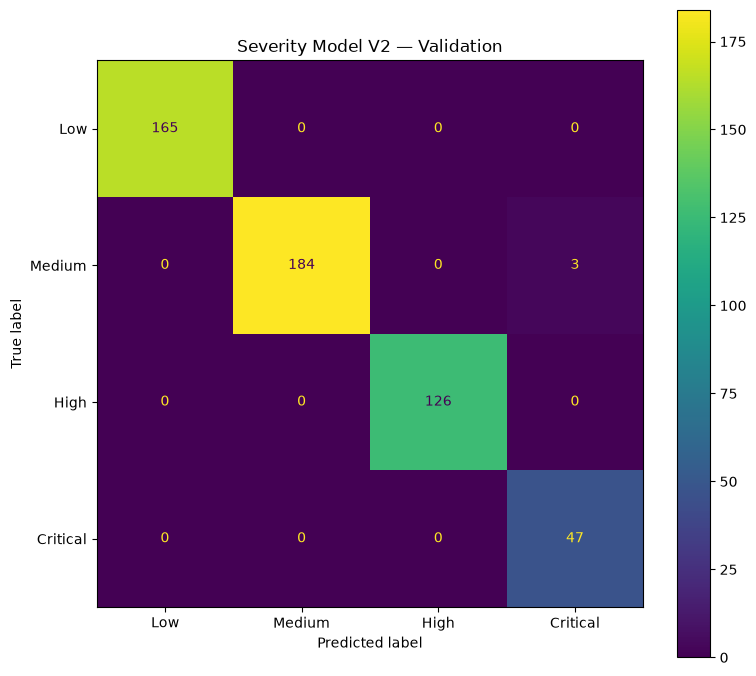

In [93]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 7))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_sev_val_pred_v2,
    labels=["Low", "Medium", "High", "Critical"],
    display_labels=["Low", "Medium", "High", "Critical"],
    ax=ax
)

ax.set_title("Severity Model V2 — Validation")
plt.tight_layout()
plt.show()

In [94]:
y_sev_test_pred_v2 = severity_model_v2.predict(
    X_sev_test_final
)

print(
    "Severity V2 Test Accuracy:",
    accuracy_score(y_test, y_sev_test_pred_v2)
)

print("\nTest Classification Report:")
print(
    classification_report(
        y_test,
        y_sev_test_pred_v2,
        zero_division=0
    )
)

Severity V2 Test Accuracy: 0.9942857142857143

Test Classification Report:
              precision    recall  f1-score   support

    Critical       1.00      1.00      1.00        47
        High       1.00      0.99      1.00       126
         Low       1.00      0.99      0.99       165
      Medium       0.98      1.00      0.99       187

    accuracy                           0.99       525
   macro avg       1.00      0.99      1.00       525
weighted avg       0.99      0.99      0.99       525



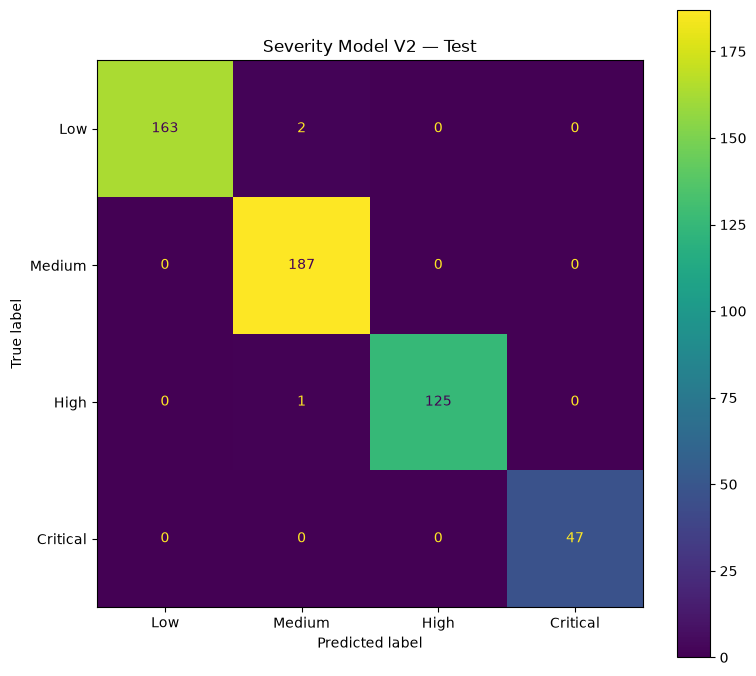

In [95]:
fig, ax = plt.subplots(figsize=(8, 7))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_sev_test_pred_v2,
    labels=["Low", "Medium", "High", "Critical"],
    display_labels=["Low", "Medium", "High", "Critical"],
    ax=ax
)

ax.set_title("Severity Model V2 — Test")
plt.tight_layout()
plt.show()

In [96]:
real_severity_tests = [
    "School ke bahar khula manhole hai aur bachche gir sakte hain.",
    "Road par chhota sa pothole hai.",
    "Paani mein badbu aa rahi hai aur logon ko bimaar hone ka dar hai.",
    "Garbage do din se collect nahi hua.",
    "Main road par bada accident hazard bana hua hai.",
    "Street light kal se kaam nahi kar rahi.",
    "Poore area mein sewage road par beh raha hai.",
    "Lake mein factory ka dirty water ja raha hai."
]

X_real_text = severity_vectorizer.transform(real_severity_tests)

# numeric features bhi same pipeline se banana hoga

In [97]:
import pandas as pd

def extract_severity_features(complaint_text):

    text = complaint_text.lower()

    features = {
        "risk_injury": int(bool(__import__("re").search(
            r"\binjur|fell|fall|accident|hurt|danger|unsafe|risk|bite|attack\b",
            text
        ))),

        "traffic_impact": int(bool(__import__("re").search(
            r"\btraffic|vehicles|vehicle|commuters|blocked road|roadblock|congestion\b",
            text
        ))),

        "public_exposure": int(bool(__import__("re").search(
            r"\bschool|children|hospital|busy road|market|public|pedestrians|residents\b",
            text
        ))),

        "health_hazard": int(bool(__import__("re").search(
            r"\bsewage|contaminated|dirty water|foul|smoke|pollution|wastewater\b",
            text
        ))),

        "urgent_language": int(bool(__import__("re").search(
            r"\burgent|immediate|dangerous|serious|severe|critical|emergency\b",
            text
        ))),

        "scale_impact": int(bool(__import__("re").search(
            r"\blarge number|many people|whole area|entire|multiple|repeatedly|daily\b",
            text
        ))),

        "text_length": len(text.split())
    }

    return pd.DataFrame([features])

In [98]:
def predict_severity(complaint_text):

    # 1. Text → TF-IDF
    text_features = severity_vectorizer.transform(
        [complaint_text]
    )

    # 2. Complaint → numeric/context features
    numeric_features = extract_severity_features(
        complaint_text
    )

    # 3. Scale numeric features
    numeric_features_scaled = scaler.transform(
        numeric_features
    )

    # 4. Combine text + numeric features
    final_features = __import__("scipy").sparse.hstack([
        text_features,
        numeric_features_scaled
    ])

    # 5. Predict severity
    prediction = severity_model_v2.predict(
        final_features
    )[0]

    # 6. Prediction confidence
    probabilities = severity_model_v2.predict_proba(
        final_features
    )[0]

    confidence = probabilities.max()


    return prediction, confidence

In [99]:
test_complaints = [
    "There is a small pothole on a quiet residential lane.",
    "An open manhole near a school is extremely dangerous and children could fall.",
    "Garbage has not been collected for two days.",
    "Dirty contaminated water with a strong smell is coming from the taps.",
    "A large number of vehicles are affected by a blocked road.",
    "The street light near my house is not working."
]

for complaint in test_complaints:

    severity, confidence = predict_severity(
        complaint
    )

    print(
        f"{severity:8} | "
        f"{confidence:.3f} | "
        f"{complaint}"
    )

Low      | 0.517 | There is a small pothole on a quiet residential lane.
Critical | 0.679 | An open manhole near a school is extremely dangerous and children could fall.
Medium   | 0.446 | Garbage has not been collected for two days.
Low      | 0.404 | Dirty contaminated water with a strong smell is coming from the taps.
Medium   | 0.981 | A large number of vehicles are affected by a blocked road.
Low      | 0.526 | The street light near my house is not working.


In [100]:
print(sev.columns.tolist())

['complaint_id', 'complaint_text', 'is_civic', 'area', 'sub_category', 'department', 'severity', 'source_type', 'text_length_words', 'text_length_chars', 'text_clean', 'risk_injury', 'traffic_impact', 'public_exposure', 'health_hazard', 'urgent_language', 'scale_impact', 'text_length']


In [101]:
print(
    sev[
        ["complaint_text", "area", "sub_category", "severity"]
    ].head()
)

                                      complaint_text               area  \
0  A pothole in the road near the colony entrance...  Roads & Footpaths   
1  People living nearby say a deep pothole along ...  Roads & Footpaths   
2  The area has been affected by a large road cra...  Roads & Footpaths   
3  The problem involves several potholes on the l...  Roads & Footpaths   
4  The civic issue was noticed along the resident...  Roads & Footpaths   

  sub_category severity  
0      Pothole      Low  
1      Pothole   Medium  
2      Pothole   Medium  
3      Pothole     High  
4      Pothole      Low  


In [102]:
sev["severity_context"] = (
    sev["complaint_text"].fillna("") + " "
    + sev["area"].fillna("") + " "
    + sev["sub_category"].fillna("")
)

print(
    sev[
        ["complaint_text", "area", "sub_category", "severity_context"]
    ].head()
)

                                      complaint_text               area  \
0  A pothole in the road near the colony entrance...  Roads & Footpaths   
1  People living nearby say a deep pothole along ...  Roads & Footpaths   
2  The area has been affected by a large road cra...  Roads & Footpaths   
3  The problem involves several potholes on the l...  Roads & Footpaths   
4  The civic issue was noticed along the resident...  Roads & Footpaths   

  sub_category                                   severity_context  
0      Pothole  A pothole in the road near the colony entrance...  
1      Pothole  People living nearby say a deep pothole along ...  
2      Pothole  The area has been affected by a large road cra...  
3      Pothole  The problem involves several potholes on the l...  
4      Pothole  The civic issue was noticed along the resident...  


In [103]:
X_context = sev["severity_context"]
X_num = sev[numeric_cols]
y = sev["severity"]

(
    X_context_train,
    X_context_temp,
    X_num_train_v3,
    X_num_temp_v3,
    y_train_v3,
    y_temp_v3
) = train_test_split(
    X_context,
    X_num,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

(
    X_context_val,
    X_context_test,
    X_num_val_v3,
    X_num_test_v3,
    y_val_v3,
    y_test_v3
) = train_test_split(
    X_context_temp,
    X_num_temp_v3,
    y_temp_v3,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_v3
)

print("Train:", len(X_context_train))
print("Validation:", len(X_context_val))
print("Test:", len(X_context_test))

Train: 2450
Validation: 525
Test: 525


In [104]:
from sklearn.feature_extraction.text import TfidfVectorizer

severity_vectorizer_v3 = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

X_context_train_tfidf = severity_vectorizer_v3.fit_transform(
    X_context_train
)

X_context_val_tfidf = severity_vectorizer_v3.transform(
    X_context_val
)

X_context_test_tfidf = severity_vectorizer_v3.transform(
    X_context_test
)

print("Context train:", X_context_train_tfidf.shape)
print("Context validation:", X_context_val_tfidf.shape)
print("Context test:", X_context_test_tfidf.shape)

print(
    "Vocabulary size:",
    len(severity_vectorizer_v3.vocabulary_)
)


Context train: (2450, 4527)
Context validation: (525, 4527)
Context test: (525, 4527)
Vocabulary size: 4527


In [105]:
from sklearn.preprocessing import StandardScaler

severity_scaler_v3 = StandardScaler()

X_num_train_v3_scaled = severity_scaler_v3.fit_transform(
    X_num_train_v3
)

X_num_val_v3_scaled = severity_scaler_v3.transform(
    X_num_val_v3
)

X_num_test_v3_scaled = severity_scaler_v3.transform(
    X_num_test_v3
)

print("Numeric train:", X_num_train_v3_scaled.shape)
print("Numeric validation:", X_num_val_v3_scaled.shape)
print("Numeric test:", X_num_test_v3_scaled.shape)

Numeric train: (2450, 7)
Numeric validation: (525, 7)
Numeric test: (525, 7)


In [106]:
from scipy.sparse import hstack

X_sev_train_v3 = hstack([
    X_context_train_tfidf,
    X_num_train_v3_scaled
])

X_sev_val_v3 = hstack([
    X_context_val_tfidf,
    X_num_val_v3_scaled
])

X_sev_test_v3 = hstack([
    X_context_test_tfidf,
    X_num_test_v3_scaled
])

print("Final V3 train:", X_sev_train_v3.shape)
print("Final V3 validation:", X_sev_val_v3.shape)
print("Final V3 test:", X_sev_test_v3.shape)

Final V3 train: (2450, 4534)
Final V3 validation: (525, 4534)
Final V3 test: (525, 4534)


In [107]:
from sklearn.linear_model import LogisticRegression

severity_model_v3 = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    random_state=42
)

severity_model_v3.fit(
    X_sev_train_v3,
    y_train_v3
)

print("Severity Model V3 trained successfully ✅")

Severity Model V3 trained successfully ✅


In [108]:
from sklearn.metrics import accuracy_score, classification_report

y_sev_val_pred_v3 = severity_model_v3.predict(
    X_sev_val_v3
)

print(
    "Severity V3 Validation Accuracy:",
    accuracy_score(y_val_v3, y_sev_val_pred_v3)
)

print("\nClassification Report:")
print(
    classification_report(
        y_val_v3,
        y_sev_val_pred_v3,
        zero_division=0
    )
)

Severity V3 Validation Accuracy: 0.9942857142857143

Classification Report:
              precision    recall  f1-score   support

    Critical       0.96      1.00      0.98        47
        High       0.99      1.00      1.00       126
         Low       1.00      1.00      1.00       165
      Medium       1.00      0.98      0.99       187

    accuracy                           0.99       525
   macro avg       0.99      1.00      0.99       525
weighted avg       0.99      0.99      0.99       525



In [109]:
from sklearn.metrics import accuracy_score, classification_report

y_sev_test_pred_v3 = severity_model_v3.predict(
    X_sev_test_v3
)

print(
    "Severity V3 Test Accuracy:",
    accuracy_score(y_test_v3, y_sev_test_pred_v3)
)

print("\nClassification Report:")
print(
    classification_report(
        y_test_v3,
        y_sev_test_pred_v3,
        zero_division=0
    )
)

Severity V3 Test Accuracy: 0.9923809523809524

Classification Report:
              precision    recall  f1-score   support

    Critical       1.00      1.00      1.00        47
        High       1.00      0.98      0.99       126
         Low       1.00      0.99      0.99       165
      Medium       0.98      1.00      0.99       187

    accuracy                           0.99       525
   macro avg       0.99      0.99      0.99       525
weighted avg       0.99      0.99      0.99       525



In [110]:
def predict_severity_v3(complaint_text, area, sub_category):
    text_context = (
        complaint_text + " " +
        area + " " +
        sub_category
    )

    text_features = severity_vectorizer_v3.transform(
        [text_context]
    )

    numeric_features = extract_severity_features(
        complaint_text
    )

    numeric_features_scaled = (
        severity_scaler_v3.transform(numeric_features)
    )

    final_features = __import__("scipy").sparse.hstack([
        text_features,
        numeric_features_scaled
    ])

    prediction = severity_model_v3.predict(
        final_features
    )[0]

    probabilities = severity_model_v3.predict_proba(
        final_features
    )[0]

    confidence = probabilities.max()

    return prediction, confidence

In [111]:
natural_severity_tests_v3 = [
    {
        "text": "There is a small pothole on a quiet residential lane.",
        "area": "Roads & Footpaths",
        "sub_category": "Pothole"
    },
    {
        "text": "A deep pothole near a school is causing bikes to lose balance.",
        "area": "Roads & Footpaths",
        "sub_category": "Pothole"
    },
    {
        "text": "An open manhole on a busy road is extremely dangerous and children could fall.",
        "area": "Sewerage & Drainage",
        "sub_category": "Manhole Issue"
    },
    {
        "text": "The street light near my house has stopped working.",
        "area": "Street Lighting",
        "sub_category": "Street Light Not Working"
    },
    {
        "text": "Our apartment has had no water supply since this morning.",
        "area": "Water Supply",
        "sub_category": "No Water Supply"
    },
    {
        "text": "Dirty contaminated water with a strong smell is coming from the taps.",
        "area": "Water Supply",
        "sub_category": "Contaminated Water"
    },
    {
        "text": "Garbage has not been collected for two days.",
        "area": "Waste Management",
        "sub_category": "Garbage Not Collected"
    },
    {
        "text": "A huge pile of garbage is blocking the road and traffic.",
        "area": "Waste Management",
        "sub_category": "Illegal Garbage Dumping"
    },
    {
        "text": "Sewage is overflowing onto the road near a hospital.",
        "area": "Sewerage & Drainage",
        "sub_category": "Sewage Overflow"
    },
    {
        "text": "A fallen tree is completely blocking the main road.",
        "area": "Trees & Greenery",
        "sub_category": "Fallen Tree"
    },
    {
        "text": "There is loud construction noise disturbing the entire neighborhood every night.",
        "area": "Pollution & Environment",
        "sub_category": "Noise Pollution"
    },
    {
        "text": "The park playground equipment is slightly damaged but still usable.",
        "area": "Parks & Recreation",
        "sub_category": "Damaged Playground Equipment"
    }
]

for item in natural_severity_tests_v3:

    prediction, confidence = predict_severity_v3(
        item["text"],
        item["area"],
        item["sub_category"]
    )

    print(
        f"{prediction:8} | "
        f"{confidence:.3f} | "
        f"{item['text']}"
    )

Low      | 0.520 | There is a small pothole on a quiet residential lane.
Low      | 0.596 | A deep pothole near a school is causing bikes to lose balance.
Critical | 0.727 | An open manhole on a busy road is extremely dangerous and children could fall.
Low      | 0.609 | The street light near my house has stopped working.
Low      | 0.519 | Our apartment has had no water supply since this morning.
Low      | 0.419 | Dirty contaminated water with a strong smell is coming from the taps.
Low      | 0.458 | Garbage has not been collected for two days.
Medium   | 0.822 | A huge pile of garbage is blocking the road and traffic.
Low      | 0.594 | Sewage is overflowing onto the road near a hospital.
High     | 0.961 | A fallen tree is completely blocking the main road.
Medium   | 0.752 | There is loud construction noise disturbing the entire neighborhood every night.
Low      | 0.530 | The park playground equipment is slightly damaged but still usable.


Severity V3 Confusion Matrix:
[[ 47   0   0   0]
 [  0 124   0   2]
 [  0   0 163   2]
 [  0   0   0 187]]


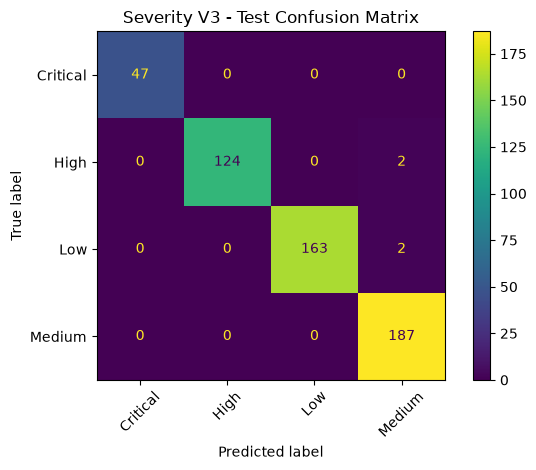

In [112]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_v3 = confusion_matrix(
    y_test_v3,
    y_sev_test_pred_v3,
    labels=severity_model_v3.classes_
)

print("Severity V3 Confusion Matrix:")
print(cm_v3)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_v3,
    display_labels=severity_model_v3.classes_
)

disp.plot(xticks_rotation=45)
plt.title("Severity V3 - Test Confusion Matrix")
plt.tight_layout()
plt.show()

In [113]:
wrong_indices_v3 = y_test_v3 != y_sev_test_pred_v3

wrong_v3 = sev.loc[
    y_test_v3.index[wrong_indices_v3],
    ["complaint_text", "area", "sub_category", "severity"]
].copy()

wrong_v3["actual_severity"] = y_test_v3[wrong_indices_v3].values
wrong_v3["predicted_severity"] = y_sev_test_pred_v3[wrong_indices_v3]

wrong_v3

,complaint_text,area,sub_category,severity,actual_severity,predicted_severity
1381,Please check vehicles speeding through a resid...,Traffic & Road Safety,Dangerous Driving,High,High,Medium
1056,A civic inspection is requested for a bent lam...,Street Lighting,Damaged Light Pole,High,High,Medium
2378,The issue was reported by commuters who notice...,Trees & Greenery,Tree Plantation,Low,Low,Medium
2358,The issue was reported by commuters who notice...,Trees & Greenery,Tree Plantation,Low,Low,Medium


In [114]:
check_categories = sev[
    sev["sub_category"].isin([
        "Dangerous Driving",
        "Damaged Light Pole",
        "Tree Plantation"
    ])
][[
    "complaint_text",
    "area",
    "sub_category",
    "severity"
]]

check_categories

,complaint_text,area,sub_category,severity
1050,A damaged street-light pole near the public ho...,Street Lighting,Damaged Light Pole,Medium
1051,People living nearby say a bent lamp post clos...,Street Lighting,Damaged Light Pole,High
1052,The area has been affected by a light pole wit...,Street Lighting,Damaged Light Pole,High
1053,The problem involves a cracked lighting pole n...,Street Lighting,Damaged Light Pole,Medium
1054,The civic issue was noticed close to the main ...,Street Lighting,Damaged Light Pole,Critical
...,...,...,...,...
2375,People using the area have pointed out the nee...,Trees & Greenery,Tree Plantation,Low
2376,Several people have raised concerns about a re...,Trees & Greenery,Tree Plantation,Low
2377,There has been an area suitable for public tre...,Trees & Greenery,Tree Plantation,Medium
2378,The issue was reported by commuters who notice...,Trees & Greenery,Tree Plantation,Low


In [115]:
sev[
    sev["sub_category"].isin([
        "Dangerous Driving",
        "Damaged Light Pole",
        "Tree Plantation"
    ])
].groupby(
    ["sub_category", "severity"]
).size()

sub_category        severity
Damaged Light Pole  Critical     7
                    High        14
                    Medium      14
Dangerous Driving   Critical     7
                    High        14
                    Medium      14
Tree Plantation     Low         21
                    Medium      14
dtype: int64

In [116]:
import pandas as pd
from scipy.sparse import hstack

wrong_probability_rows = []

for idx in y_test_v3.index[wrong_indices_v3]:

    complaint = sev.loc[idx, "complaint_text"]
    area = sev.loc[idx, "area"]
    sub_category = sev.loc[idx, "sub_category"]

    context = (
        complaint + " " +
        area + " " +
        sub_category
    )

    text_features = severity_vectorizer_v3.transform(
        [context]
    )

    numeric_features = extract_severity_features(
        complaint
    )

    numeric_features_scaled = (
        severity_scaler_v3.transform(numeric_features)
    )

    final_features = hstack([
        text_features,
        numeric_features_scaled
    ])

    probabilities = severity_model_v3.predict_proba(
        final_features
    )[0]

    row = {
        "index": idx,
        "complaint_text": complaint,
        "area": area,
        "sub_category": sub_category,
        "actual": y_test_v3.loc[idx],
        "predicted": severity_model_v3.predict(final_features)[0]
    }

    for cls, prob in zip(
        severity_model_v3.classes_,
        probabilities
    ):
        row[f"prob_{cls}"] = round(prob, 3)

    wrong_probability_rows.append(row)

wrong_probability_df = pd.DataFrame(
    wrong_probability_rows
)

wrong_probability_df

,index,complaint_text,area,sub_category,actual,predicted,prob_Critical,prob_High,prob_Low,prob_Medium
0,1381,Please check vehicles speeding through a resid...,Traffic & Road Safety,Dangerous Driving,High,Medium,0.0,0.465,0.060,0.475
1,1056,A civic inspection is requested for a bent lam...,Street Lighting,Damaged Light Pole,High,Medium,0.0,0.346,0.140,0.514
2,2378,The issue was reported by commuters who notice...,Trees & Greenery,Tree Plantation,Low,Medium,0.0,0.052,0.179,0.769
3,2358,The issue was reported by commuters who notice...,Trees & Greenery,Tree Plantation,Low,Medium,0.0,0.081,0.168,0.750


In [117]:
import numpy as np

feature_names = (
    list(severity_vectorizer_v3.get_feature_names_out())
    + numeric_cols
)

for class_name, coefficients in zip(
    severity_model_v3.classes_,
    severity_model_v3.coef_
):
    top_indices = np.argsort(coefficients)[-15:][::-1]

    print(f"\n===== {class_name} =====")

    for idx in top_indices:
        print(
            f"{feature_names[idx]:30} "
            f"{coefficients[idx]:.4f}"
        )


===== Critical =====
urgent_language                2.1482
exposed to                     1.1491
is exposed                     1.1491
serious hazard                 1.1491
to serious                     1.1491
public is                      1.0739
the public                     1.0316
exposed                        0.9917
hazard                         0.9071
risk_injury                    0.8723
is dangerous                   0.8552
right now                      0.8419
now                            0.8419
situation is                   0.8419
dangerous right                0.8419

===== High =====
significant                    1.9535
the disruption                 1.9535
is significant                 1.9535
disruption is                  1.9535
urgent action                  1.7058
asking for                     1.7058
urgent                         1.7058
for urgent                     1.7058
becoming unsafe                1.4522
normal access                  1.4522
access is 

In [118]:
from pathlib import Path

models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

print("Models folder:", models_dir.resolve())

Models folder: C:\desktop project\CivicAI\ml\models


In [119]:
print([name for name in globals() if "model" in name.lower()])
print([name for name in globals() if "vector" in name.lower()])

['model', 'area_model', 'road_model', 'sub_model', 'fold_model', 'sewer_model', 'severity_model_v2', 'severity_model_v3', 'models_dir']
['TfidfVectorizer', 'vectorizer', 'area_vectorizer', 'road_vectorizer', 'sub_vectorizer', 'sim_vectorizer', 'fold_vectorizer', 'sewer_vectorizer', 'severity_vectorizer', 'severity_vectorizer_v3']


In [120]:
import joblib

joblib.dump(model, models_dir / "civic_model.joblib")
joblib.dump(vectorizer, models_dir / "civic_vectorizer.joblib")

print("Model 1 saved successfully ✅")

Model 1 saved successfully ✅


In [121]:
print(list(models_dir.iterdir()))

[WindowsPath('../models/civic_model.joblib'), WindowsPath('../models/civic_vectorizer.joblib')]


In [122]:
joblib.dump(area_model, models_dir / "area_model.joblib")
joblib.dump(area_vectorizer, models_dir / "area_vectorizer.joblib")

print("Model 2 saved successfully ✅")

Model 2 saved successfully ✅


In [123]:
joblib.dump(sub_model, models_dir / "subcategory_model.joblib")
joblib.dump(sub_vectorizer, models_dir / "subcategory_vectorizer.joblib")

print("Model 3 saved successfully ✅")

Model 3 saved successfully ✅


In [124]:
joblib.dump(
    severity_model_v3,
    models_dir / "severity_model_v3.joblib"
)

joblib.dump(
    severity_vectorizer_v3,
    models_dir / "severity_vectorizer_v3.joblib"
)

joblib.dump(
    severity_scaler_v3,
    models_dir / "severity_scaler_v3.joblib"
)

print("Model 4 (Severity V3) saved successfully ✅")


Model 4 (Severity V3) saved successfully ✅


In [125]:
for file in sorted(models_dir.iterdir()):
    print(file.name)

area_model.joblib
area_vectorizer.joblib
civic_model.joblib
civic_vectorizer.joblib
severity_model_v3.joblib
severity_scaler_v3.joblib
severity_vectorizer_v3.joblib
subcategory_model.joblib
subcategory_vectorizer.joblib
